<a href="https://colab.research.google.com/github/johnryantaylor/QCES/blob/main/Project2_transport.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 2: Tracer transport

A critical aspect of understanding climate and environmental systems is describing the movement of substances. This could include pollution or water vapor in the atmosphere, salt in an estuary, or chemicals in a river. We often model the transport of these substances using an advection/diffusion equation for the concentration of the substance. In this context, we sometimes refer to the concentration field as a `tracer' since it helps us track the movement of individual molecules. We can also use this framework to describe the transport of heat, although in this case the tracer field (temperature or heat content) tracks the movement of thermal energy.

In this project we will use Dedalus to solve advection diffusion equations to describe the vertical distribution of heat in the ocean and the concentration of pollution in a river.

Student tasks are in [Section 1.4](#section1pt4), [Section 1.6](#section1pt6), and [Section 2.3](#section2pt3)

## Setup
If you are using Google colab, run the script below to install Dedalus

In [1]:
# Set environment variables for best performance
%env OMP_NUM_THREADS=1
%env NUMEXPR_MAX_THREADS=1

# Minimize logging output
import logging
logging.disable(logging.DEBUG)

# Check if running on google colab
import os
using_google_colab = bool(os.getenv("COLAB_RELEASE_TAG"))

# Check for Dedalus
try:
    import dedalus.public as de
    print("Dedalus already installed :)")
except:
    print("Dedalus not installed yet.")
    if using_google_colab:
        print("Installing for Google Colab.")
        print()
        # Step 1: Install FFTW
        !apt-get install libfftw3-dev
        !apt-get install libfftw3-mpi-dev
        # Step 2: Set paths for Dedalus installation
        import os
        os.environ['MPI_INCLUDE_PATH'] = "/usr/lib/x86_64-linux-gnu/openmpi/include"
        os.environ['MPI_LIBRARY_PATH'] = "/usr/lib/x86_64-linux-gnu"
        os.environ['FFTW_INCLUDE_PATH'] = "/usr/include"
        os.environ['FFTW_LIBRARY_PATH'] = "/usr/lib/x86_64-linux-gnu"
        # Step 3: Install Dedalus using pip
        !pip3 install cython "mpi4py<4.0" numpy setuptools wheel
        !CC=mpicc pip3 install --no-cache --no-build-isolation http://github.com/dedalusproject/dedalus/zipball/master/
        !pip3 install -q ipympl
        # Step 4: Check installation
        print()
        try:
            import dedalus.public as de
            print("Dedalus successfully installed :)")
        except:
            print("Error installing Dedalus :(")
            raise
    else:
        print("See website for installation instructions:")
        print("https://dedalus-project.readthedocs.io/en/latest/pages/installation.html")

# Setup interactive matplotlib
if using_google_colab:
    from google.colab import output
    output.enable_custom_widget_manager()

env: OMP_NUM_THREADS=1
env: NUMEXPR_MAX_THREADS=1
Dedalus already installed :)


## 1. Thermal structure in the ocean

Most of the ocean has a stable thermal stratification with warm water at the surface and cold water in the abyss (exceptions occur in salt-stratified waters like the Arctic Ocean). Since the ocean is a massive thermal reservoir, understanding the distribution of this heat is important to quantifying the ocean's role in a changing climate. The structure of the temperature field can also inform us about the circulation in the ocean interior.


### 1.1 Measured temperature profile

The code below plots a sample temperature profile obtained off the coast of California. The data was obtained by digitizing Figure 3 in Munk, 1966.

Text(0, 0.5, 'Depth (m)')

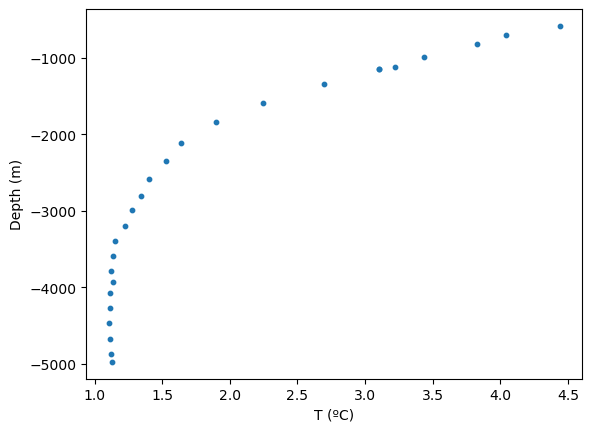

In [2]:
import matplotlib.pyplot as plt

# Temperature measurements extracted from Figure 3 in Munk, 1966
CTD_T = [1.1296296296296295, 1.122004357298475, 1.1143790849673203, 1.1067538126361656, 1.1143790849673203, 1.1143790849673203, 1.1372549019607843, 1.122004357298475, 1.1372549019607843, 1.1525054466230937, 1.2287581699346406, 1.2745098039215685, 1.343137254901961, 1.4041394335511983, 1.526143790849673, 1.6405228758169934, 1.8997821350762527, 2.242919389978214, 2.69281045751634, 3.104575163398693, 3.104575163398693, 3.218954248366013, 3.4324618736383443, 3.8289760348583877, 4.042483660130719, 4.438997821350762]
CTD_z = [-4976.958525345623, -4869.431643625192, -4677.419354838709, -4470.046082949309, -4270.353302611367, -4070.6605222734256, -3932.411674347158, -3786.4823348694317, -3586.78955453149, -3394.7772657450078, -3195.084485407066, -2995.3917050691243, -2803.379416282642, -2580.6451612903224, -2350.230414746544, -2112.1351766513058, -1843.3179723502303, -1597.5422427035332, -1344.0860215053763, -1144.3932411674346, -1144.3932411674346, -1121.351766513057, -990.7834101382491, -821.8125960061443, -698.9247311827958, -583.7173579109067]

plt.scatter(CTD_T,CTD_z,s=10)
plt.xlabel('T (ºC)')
plt.ylabel('Depth (m)')


### 1.2 Abyssal recipes

Munk (1966) proposed that the thermal structure of the ocean interior is set by a balance between upwelling and diffusion. In this view, cold waters sink near the poles and spread across the seafloor before slowly rising through the ocean interior. If we assume, as Munk did, that the water upwells uniformly across the globe, the upwelling speed is approximately $10^{-7}$ m/s. This is far too small to directly measure, but it is large enough to have a major impact on the distribution of tracers. Since light can only penetrate through the top ~100m of ocean, we can ignore solar heating, except in that it sets the temperature near the ocean surface.

### 1.3 Steady advection/diffusion equation

Dedalus can solve differential equations in various forms. In addition to time-dependent initial value problems (IVPs), Dedalus can solve linear and nonlinear boundary value problems. The code below uses Dedalus to solve a linear boundary value problem (IVBP) for the steady state advection/diffusion equation. 

Here, the top and bottom temperature are set from the measured profile and these are used as boundary conditions. The vertical (upwelling) velocity is set to $10^{-7} m/s$, and the diffusivity is set to $10^{-7}$ $m^2/s$, to approximate the molecular diffusivity of heat in seawater. 

2025-11-12 08:38:11,561 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 0s, Remaining: 0s, Rate: 2.4e+01/s


Text(0, 0.5, 'Depth (m)')

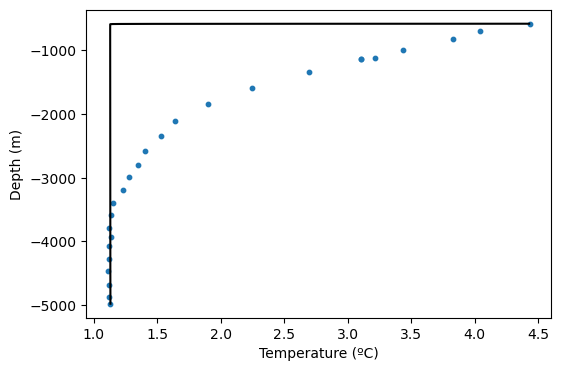

In [3]:
"""
Dedalus script to solve the steady advection/diffusion equation
"""

import numpy as np
import matplotlib.pyplot as plt
import dedalus.public as d3
import logging
logger = logging.getLogger(__name__)

# Set various parameters. Note that the depth and the top and bottom temperature 
# are taken from the CTD data in the code cell above. That cell must be run first to define CTD_T and CTD_z.
z_surface = CTD_z[-1]
z_bottom = CTD_z[0]
T_surface = CTD_T[-1]
T_bottom = CTD_T[0]
Nz = 1000

# Set the upwelling velocity
w = 1e-7 # m/s
# Set the diffusivity
kappa=1e-7 # m^2/s

# Bases
zcoord = d3.Coordinate('z')
dist = d3.Distributor(zcoord, dtype=np.float64)
zbasis = d3.Chebyshev(zcoord, size=Nz, bounds=(z_bottom, z_surface))
z = dist.local_grid(zbasis)

# Fields
T = dist.Field(name='T', bases=zbasis)

# Add two tau variables to allow us to apply two boundary conditions
tau_1 = dist.Field(name='tau_1')
tau_2 = dist.Field(name='tau_2')
lift_basis = zbasis.derivative_basis(1)
lift = lambda A: d3.Lift(A, lift_basis, -1)

# Substitutions
dz = lambda A: d3.Differentiate(A, zcoord)
Tz = dz(T) + lift(tau_1)
Tzz = dz(Tz) + lift(tau_2)

# Problem
problem = d3.LBVP([T, tau_1, tau_2], namespace=locals())
problem.add_equation("w*Tz - kappa*Tzz = 0")
problem.add_equation("T(z=z_surface) = T_surface")
problem.add_equation("T(z=z_bottom) = T_bottom")

# Solver
solver = problem.build_solver()
solver.solve()

# Plot
plt.figure(figsize=(6, 4))
Tg=T['g']
plt.scatter(CTD_T,CTD_z,s=10)
plt.plot(Tg,z,'k')
plt.xlabel('Temperature (ºC)')
plt.ylabel('Depth (m)')

### 1.4 Student investigation
<a id='section1pt4'></a>
Note that the profile above is not a good fit to the data. This implies that molecular diffusion isn't sufficient to transport heat down from the surface and stop the ocean from filling up with cold, dense water. 

Munk (1966) proposed that small-scale turbulence in the ocean interior results in a diffusivity that is orders of magnitude larger than the molecular value. Find a diffusivity that gives a good match with the data and test it in the Dedalus script above. Comment on the ability of this model (steady advection/diffusion) to fit the data. 

2025-11-12 08:38:11,972 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 0s, Remaining: 0s, Rate: 1.4e+01/s
2025-11-12 08:38:12,018 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 0s, Remaining: 0s, Rate: 2.5e+01/s
2025-11-12 08:38:12,067 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 0s, Remaining: 0s, Rate: 2.4e+01/s
2025-11-12 08:38:12,115 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 0s, Remaining: 0s, Rate: 2.4e+01/s
2025-11-12 08:38:12,176 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 0s, Remaining: 0s, Rate: 1.8e+01/s
2025-11-12 08:38:12,223 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 0s, Remaining: 0s, Rate: 2.4e+01/s
2025-11-12 08:38:12,269 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 0s, Remaining: 0s, Rate: 2.5e+01/s
2025-11-12 08:38:12,315 subsystems 0/1 INFO :: Building subproblem matrices 

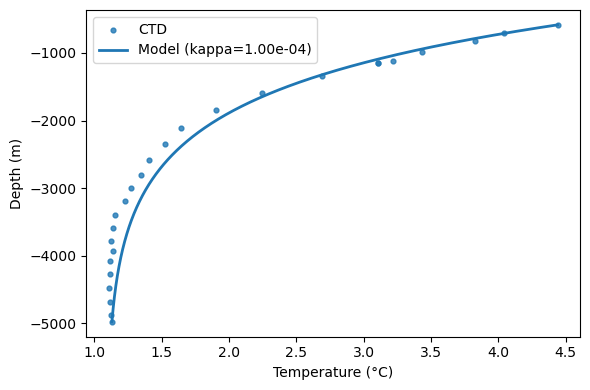

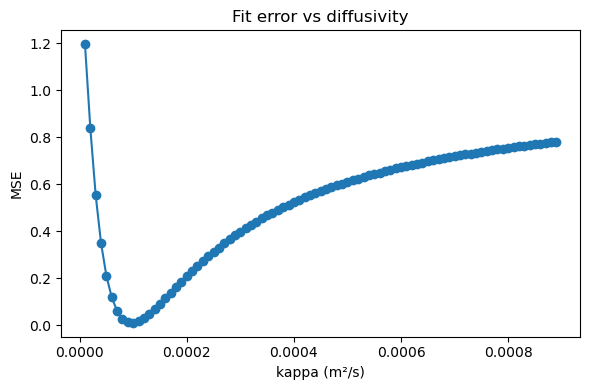

In [4]:
def steady_advection_diffusion_profile(kappa, w=1e-7, Nz=1000):
    z_surface = CTD_z[-1]
    z_bottom  = CTD_z[0]
    T_surface = CTD_T[-1]
    T_bottom  = CTD_T[0]

    zcoord = d3.Coordinate('z')
    dist   = d3.Distributor(zcoord, dtype=np.float64)
    zbasis = d3.Chebyshev(zcoord, size=Nz, bounds=(z_bottom, z_surface))
    z = dist.local_grid(zbasis)

    T = dist.Field(name='T', bases=zbasis)

    tau_1 = dist.Field(name='tau_1')
    tau_2 = dist.Field(name='tau_2')
    lift_basis = zbasis.derivative_basis(1)
    lift = lambda A: d3.Lift(A, lift_basis, -1)

    dz = lambda A: d3.Differentiate(A, zcoord)
    Tz  = dz(T) + lift(tau_1)
    Tzz = dz(Tz) + lift(tau_2)

    problem = d3.LBVP([T, tau_1, tau_2], namespace=locals())
    problem.add_equation("w*Tz - kappa*Tzz = 0")
    problem.add_equation("T(z=z_surface) = T_surface")
    problem.add_equation("T(z=z_bottom)  = T_bottom")

    solver = problem.build_solver()
    solver.solve()

    return np.array(z), np.array(T['g'])

def misfit_for_kappa(kappa):
    z_model, T_model = steady_advection_diffusion_profile(kappa)
    T_model_on_CTD = np.interp(CTD_z, z_model, T_model)
    mse = np.mean((T_model_on_CTD - CTD_T)**2)
    return mse, (z_model, T_model)

# Initializing kappa values and list
kappa_values = np.arange(1e-5, 9e-4, 1e-5)
errors = []
solutions = {} 

# Iterating through the kappa values and calculating the mse. 
for k in kappa_values:
    mse, sol = misfit_for_kappa(k)
    errors.append(mse)
    solutions[k] = sol

best_idx = int(np.argmin(errors))
best_kappa = float(kappa_values[best_idx])
best_mse = float(errors[best_idx])
z_best, T_best = solutions[best_kappa]

print(f"Best kappa = {best_kappa:.2e} m^2/s  (MSE = {best_mse:.5g})")

# Plotting best fit model
plt.figure(figsize=(6,4))
plt.scatter(CTD_T, CTD_z, s=12, label='CTD', alpha=0.8)
plt.plot(T_best, z_best, lw=2, label=f'Model (kappa={best_kappa:.2e})')
plt.xlabel('Temperature (°C)')
plt.ylabel('Depth (m)')
plt.legend()
plt.tight_layout()
plt.show()

# Plotting error vs kappa
plt.figure(figsize=(6,4))
plt.plot(kappa_values, errors, marker='o')
plt.xlabel('kappa (m²/s)')
plt.ylabel('MSE')
plt.title('Fit error vs diffusivity')
plt.tight_layout()
plt.show()

**ANSWER:** After an initial test, I decided to iterate $\kappa$ between 1e-5 and 9e-4 and then solve for a solution. Afterwards, I calculated the mean squared error on the temperature values between the Dedalus solution and the empirical values to determine that the best kappa to fit to the model is 1.00e-4. We can see from the above plots that the steady advection/diffusion model fits the data generally well. The errors are minimal at shallower depths but larger at deeper depths.

### 1.5 Turning ocean mixing upside down

Decades of research to measure the turbulent diffusivity in the ocean consistently found values much smaller than the one predicted by Munk (1966). Specifically, while larger values of the turbulent diffusivity were found near the bottom of the ocean over rough topographic features, the values in the upper ocean were about 10x smaller than the values predicted by Munk. 50 years after Munk's seminal paper, Ferrari et al. (2016) proposed that a depth-dependent turbulent diffusivity could be balanced by <em>downwelling</em>, with negative vertical velocities in the ocean interior. In this theory, the overturning circulation is upwelling in thin boundary layers along the sloping sides of the ocean basins.

When the diffusivity, $\kappa$, is a function of $z$, the steady advection/diffusion equation can be written

$$ w\frac{dT}{dz} = \frac{d}{dz}\left(\kappa(z) \frac{dT}{dz}\right)$$

The Dedalus script below solves the previous equation and again compares the results with the observed temperature profile. For the depth-dependent diffusivity, $\kappa(z)$, we take

$$ \kappa(z)=\kappa_{bg} + (\kappa_0-\kappa_{bg})e^{-(z+D)/l} $$

using the form from Rogers et al., 2023, where $\kappa_{bg}=1\times 10^{-5} m^2/s$ is the background diffusivity characteristic of the upper water column, $\kappa_0=8.6\times 10^{-4} m^2/s$ characterizes the enhanced mixing near the bottom of the ocean, $D$ is a reference depth where $\kappa=\kappa_0$, and $l=667m$ is an exponential decay scale. In the script below, we start with $w=0$. 

2025-11-12 08:38:16,507 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 0s, Remaining: 0s, Rate: 9.3e+00/s


Text(0, 0.5, 'Depth (m)')

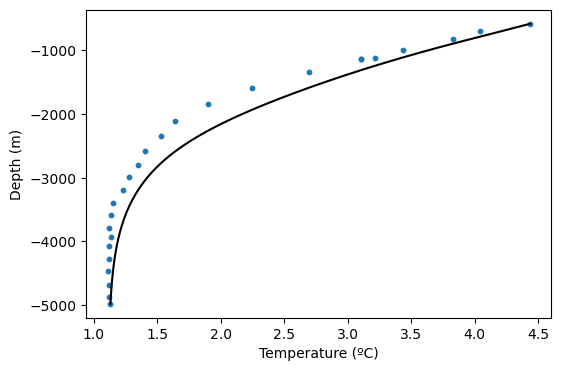

In [5]:
"""
Dedalus script to solve the steady advection/diffusion equation
with a spatially-variable diffusivity
"""

import numpy as np
import matplotlib.pyplot as plt
import dedalus.public as d3
import logging
logger = logging.getLogger(__name__)

# Set various parameters. Note that the depth and the top and bottom temperature 
# are taken from the CTD data in the code cell above. That cell must be run first to define CTD_T and CTD_z.
z_surface = CTD_z[-1]
z_bottom = CTD_z[0]
T_surface = CTD_T[-1]
T_bottom = CTD_T[0]
Nz = 1000

# Set the vertical velocity
w = 0 # m/s

# Bases
zcoord = d3.Coordinate('z')
dist = d3.Distributor(zcoord, dtype=np.float64)
zbasis = d3.Chebyshev(zcoord, size=Nz, bounds=(z_bottom, z_surface))
z = dist.local_grid(zbasis)

# Fields
T = dist.Field(name='T', bases=zbasis)
kappa = dist.Field(name='kappa', bases=zbasis)
# Set the diffusivity
# Below is the diffusivity profile from Rogers et al., 2023
kappa['g']=1e-5 + (8.6e-4-1e-5)*np.exp((-5e3-z)/667) # m^2/s

# Add two tau variables to allow us to apply two boundary conditions
tau_1 = dist.Field(name='tau_1')
tau_2 = dist.Field(name='tau_2')
lift_basis = zbasis.derivative_basis(1)
lift = lambda A: d3.Lift(A, lift_basis, -1)

# Substitutions
dz = lambda A: d3.Differentiate(A, zcoord)
Tz = dz(T) + lift(tau_1)
Tzz = dz(Tz) + lift(tau_2)

# Problem
problem = d3.LBVP([T, tau_1, tau_2], namespace=locals())
problem.add_equation("w*Tz - dz(kappa*Tz) + lift(tau_2) = 0")
problem.add_equation("T(z=z_surface) = T_surface")
problem.add_equation("T(z=z_bottom) = T_bottom")

# Solver
solver = problem.build_solver()
solver.solve()

# Plot
plt.figure(figsize=(6, 4))
Tg=T['g']
plt.scatter(CTD_T,CTD_z,s=10)
plt.plot(Tg,z,'k')
plt.xlabel('Temperature (ºC)')
plt.ylabel('Depth (m)')

### 1.6 Student investigation
<a id='section1pt6'></a>
Note from the results of the script above that the density profile is reasonable, even though $w=0$. In the box below, comment on the balance in this case and what this implies about the diffusive heat flux.

Next, find a vertical velocity that produces a better agreement with the observations and report it below. Then, try varying the details of the $\kappa(z)$ profile. How sensitive is the optimal $w$ to your choice of $\kappa(z)$? What does this imply about the circulation in the ocean interior if $\kappa(z)$ varies between regions of smooth and rough topography?

(As an aside, note that the requied vertical velocity is much smaller than the one used by Munk (1966). This implies that the dense, cold water that sinks at the poles must rise elsewhere. Ferrari et al. (2016) proposed that this occurs in boundary layers near the seafloor.)

**ANSWER:** Because $w=0$ and we had a density profile that is reasonable, this implies that the diffusive *temperature* flux throughout the ocean is relatively constant. That means that the change in kappa is balanced by the temperature gradient to keep a constant temperature flux. The diffusive *heat* flux must likewise be constant if the density of water is constant since $k = \kappa \rho c_p.$ 

### Finding an optimal vertical velocity

2025-11-12 08:38:16,676 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 0s, Remaining: 0s, Rate: 9.7e+00/s
2025-11-12 08:38:16,788 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 0s, Remaining: 0s, Rate: 9.5e+00/s
2025-11-12 08:38:16,899 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 0s, Remaining: 0s, Rate: 9.6e+00/s
2025-11-12 08:38:17,007 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 0s, Remaining: 0s, Rate: 9.8e+00/s
2025-11-12 08:38:17,117 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 0s, Remaining: 0s, Rate: 9.7e+00/s
2025-11-12 08:38:17,227 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 0s, Remaining: 0s, Rate: 9.8e+00/s
2025-11-12 08:38:17,332 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 0s, Remaining: 0s, Rate: 1.0e+01/s
2025-11-12 08:38:17,439 subsystems 0/1 INFO :: Building subproblem matrices 

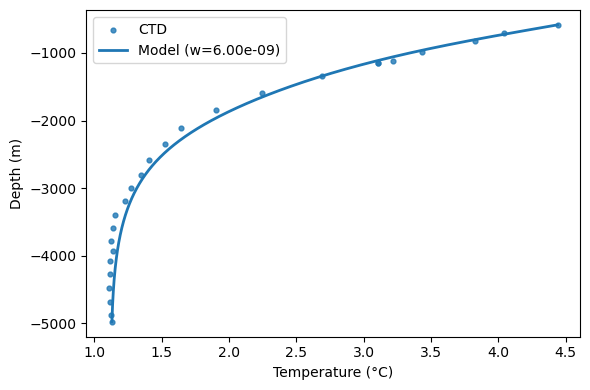

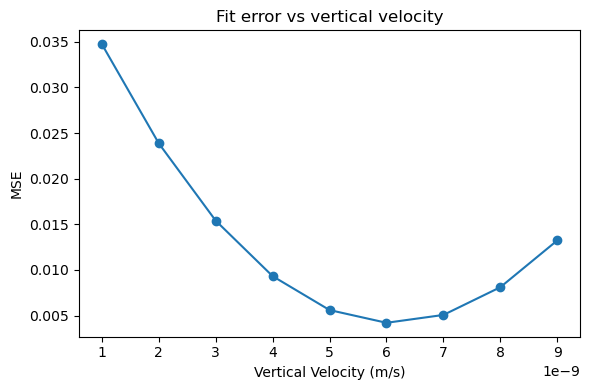

In [6]:
def steady_advection_diffusion_profile(vertical_velocity, Nz=1000):
    z_surface = CTD_z[-1]
    z_bottom = CTD_z[0]
    T_surface = CTD_T[-1]
    T_bottom = CTD_T[0]

    # Set the vertical velocity
    w = vertical_velocity # m/s

    # Bases
    zcoord = d3.Coordinate('z')
    dist = d3.Distributor(zcoord, dtype=np.float64)
    zbasis = d3.Chebyshev(zcoord, size=Nz, bounds=(z_bottom, z_surface))
    z = dist.local_grid(zbasis)

    # Fields
    T = dist.Field(name='T', bases=zbasis)
    kappa = dist.Field(name='kappa', bases=zbasis)
    # Set the diffusivity
    # Below is the diffusivity profile from Rogers et al., 2023
    kappa['g']=1e-5 + (8.6e-4-1e-5)*np.exp((-5e3-z)/667) # m^2/s

    # Add two tau variables to allow us to apply two boundary conditions
    tau_1 = dist.Field(name='tau_1')
    tau_2 = dist.Field(name='tau_2')
    lift_basis = zbasis.derivative_basis(1)
    lift = lambda A: d3.Lift(A, lift_basis, -1)

    # Substitutions
    dz = lambda A: d3.Differentiate(A, zcoord)
    Tz = dz(T) + lift(tau_1)
    Tzz = dz(Tz) + lift(tau_2)

    # Problem
    problem = d3.LBVP([T, tau_1, tau_2], namespace=locals())
    problem.add_equation("w*Tz - dz(kappa*Tz) + lift(tau_2) = 0")
    problem.add_equation("T(z=z_surface) = T_surface")
    problem.add_equation("T(z=z_bottom) = T_bottom")

    # Solver
    solver = problem.build_solver()
    solver.solve()

    return np.array(z), np.array(T['g'])

def misfit_for_w(vertical_velocity):
    z_model, T_model = steady_advection_diffusion_profile(vertical_velocity)
    T_model_on_CTD = np.interp(CTD_z, z_model, T_model)
    mse = np.mean((T_model_on_CTD - CTD_T)**2)
    return mse, (z_model, T_model)

# Initializing vertical velocity values and list
vertical_velocity_values = np.arange(1e-9, 1e-8, 1e-9)
errors = []
solutions = {} 

# Iterating through the vertical velocity values and calculating the mse. 
for w in vertical_velocity_values:
    mse, sol = misfit_for_w(w)
    errors.append(mse)
    solutions[w] = sol

best_idx = int(np.argmin(errors))
best_w = float(vertical_velocity_values[best_idx])
best_mse = float(errors[best_idx])
z_best, T_best = solutions[best_w]

print(f"Best vertical velocity = {best_w:.2e} m/s  (MSE = {best_mse:.5g})")

# Plotting best fit model
plt.figure(figsize=(6,4))
plt.scatter(CTD_T, CTD_z, s=12, label='CTD', alpha=0.8)
plt.plot(T_best, z_best, lw=2, label=f'Model (w={best_w:.2e})')
plt.xlabel('Temperature (°C)')
plt.ylabel('Depth (m)')
plt.legend()
plt.tight_layout()
plt.show()

# Plotting error vs w
plt.figure(figsize=(6,4))
plt.plot(vertical_velocity_values, errors, marker='o')
plt.xlabel('Vertical Velocity (m/s)')
plt.ylabel('MSE')
plt.title('Fit error vs vertical velocity')
plt.tight_layout()
plt.show()

**ANSWER:** We find that the optimal vertical velocity is approximately 6e-9. 

### Varying $\kappa_{bg}$, $\kappa_{0}$, and $l.$ 

In [7]:
# Depth grid for plotting kappa only
z_plot = np.linspace(-5000, 0, 5000) 

# Baseline parameter values
BASE = dict(
    kappa_bg=1e-5,
    kappa_0 = 8.6e-4,
    D       = 5000, 
    l       = 667
)

def kappa_profile(z, kappa_bg, kappa_0, D, l):
    return kappa_bg + (kappa_0 - kappa_bg) * np.exp((-D - z) / l)

# Solving the steady advection diffusion equation
def steady_advection_diffusion_profile(vertical_velocity, kappa_params, Nz=1000):
    z_surface = CTD_z[-1]    
    z_bottom  = CTD_z[0]
    T_surface = CTD_T[-1]
    T_bottom  = CTD_T[0]
    w = vertical_velocity

    # Dedalus setup
    zcoord = d3.Coordinate('z')
    dist   = d3.Distributor(zcoord, dtype=np.float64)
    zbasis = d3.Chebyshev(zcoord, size=Nz, bounds=(z_bottom, z_surface))
    z = dist.local_grid(zbasis)

    # Fields
    T     = dist.Field(name='T', bases=zbasis)
    kappa = dist.Field(name='kappa', bases=zbasis)

    # Set κ(z) from parameters
    kappa['g'] = kappa_profile(z, **kappa_params)

    # Tau lifting
    tau_1 = dist.Field(name='tau_1')
    tau_2 = dist.Field(name='tau_2')
    lift_basis = zbasis.derivative_basis(1)
    lift = lambda A: d3.Lift(A, lift_basis, -1)

    # Operators
    dz  = lambda A: d3.Differentiate(A, zcoord)
    Tz  = dz(T)  + lift(tau_1)
    Tzz = dz(Tz) + lift(tau_2)

    # LBVP
    problem = d3.LBVP([T, tau_1, tau_2], namespace=locals())
    problem.add_equation("w*Tz - dz(kappa*Tz) + lift(tau_2) = 0")
    problem.add_equation("T(z=z_surface) = T_surface")
    problem.add_equation("T(z=z_bottom)  = T_bottom")

    solver = problem.build_solver()
    solver.solve()

    return np.array(z), np.array(T['g'])

def misfit_for_w(vertical_velocity, kappa_params):
    z_model, T_model = steady_advection_diffusion_profile(vertical_velocity, kappa_params)
    T_on_CTD = np.interp(CTD_z, z_model, T_model)
    mse = np.mean((T_on_CTD - CTD_T)**2)
    return mse, (z_model, T_model)

def best_w_for_profile(kappa_params, w_grid):
    errs = []
    sols = {}
    for w in w_grid:
        mse, sol = misfit_for_w(w, kappa_params)
        errs.append(mse)
        sols[w] = sol
    idx = int(np.argmin(errs))
    best_w  = float(w_grid[idx])
    best_mse = float(errs[idx])
    return best_w, best_mse, sols[best_w], np.array(errs)


2025-11-12 08:38:17,816 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 0s, Remaining: 0s, Rate: 7.1e+00/s
2025-11-12 08:38:17,921 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 0s, Remaining: 0s, Rate: 1.0e+01/s
2025-11-12 08:38:18,028 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 0s, Remaining: 0s, Rate: 1.0e+01/s
2025-11-12 08:38:18,133 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 0s, Remaining: 0s, Rate: 1.0e+01/s
2025-11-12 08:38:18,240 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 0s, Remaining: 0s, Rate: 9.9e+00/s
2025-11-12 08:38:18,346 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 0s, Remaining: 0s, Rate: 1.0e+01/s
2025-11-12 08:38:18,453 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 0s, Remaining: 0s, Rate: 9.9e+00/s
2025-11-12 08:38:18,559 subsystems 0/1 INFO :: Building subproblem matrices 

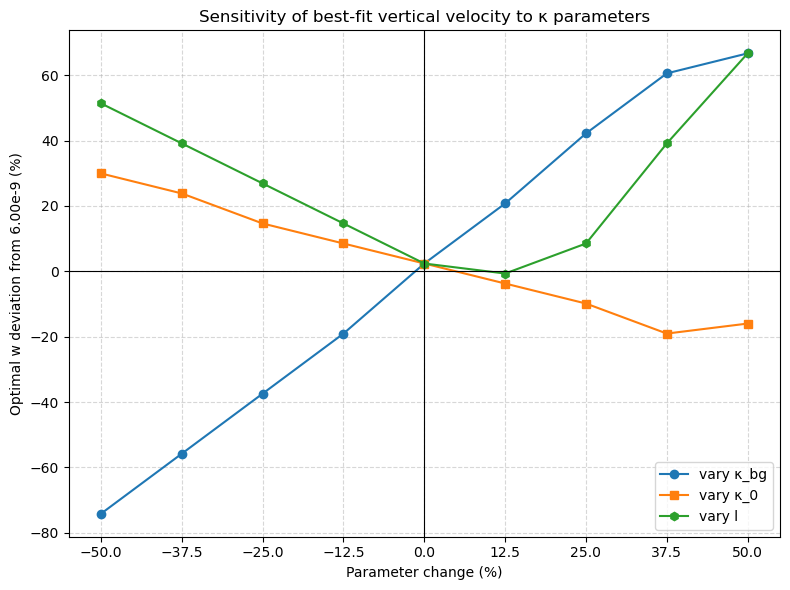

In [8]:
#Sensitivity plot: % change in kappa vs % deviation of optimal w from 6.00e-9

BASELINE_W = 6.00e-9

# Baseline parameter values
BASE = dict(
    kappa_bg=1e-5,
    kappa_0 = 8.6e-4,
    D       = 5000, 
    l       = 667
)

# Define the variation grids (±50% with 9 points => 12.5% steps)
percent_steps = np.linspace(-0.5, 0.5, 9)  # -50% to +50%
kappa_bg_vals = BASE['kappa_bg'] * (1 + percent_steps)
kappa_0_vals  = BASE['kappa_0']  * (1 + percent_steps)
l_vals = BASE['l'] * (1+percent_steps)

w_grid = np.linspace(1e-9, 1e-8, 50)

def sweep_param(param_name, values):
    x_pct = []  # % change in parameter
    y_pct = []  # % deviation in best w relative to baseline
    best_ws = []
    mses = []

    for val in values:
        params = BASE.copy()
        params[param_name] = val
        best_w, best_mse, (z_mod, T_mod), errs = best_w_for_profile(params, w_grid)
        best_ws.append(best_w)
        mses.append(best_mse)

        x_pct.append(100.0 * (val - BASE[param_name]) / BASE[param_name])
        y_pct.append(100.0 * (best_w - BASELINE_W) / BASELINE_W)

        print(f"{param_name}={val:g} ({x_pct[-1]:+.1f}%): best w = {best_w:.2e} m/s"
              f" -> deviation = {y_pct[-1]:+.2f}% (MSE={best_mse:.4g})")

    return np.array(x_pct), np.array(y_pct), np.array(best_ws), np.array(mses)

# Run the sweeps
x_bg, y_bg, best_ws_bg, mses_bg = sweep_param('kappa_bg', kappa_bg_vals)
x_k0, y_k0, best_ws_k0, mses_k0 = sweep_param('kappa_0',  kappa_0_vals)
x_l, y_l, best_ws_l, mses_l = sweep_param('l',  l_vals)

# Plot: % change in kappa (x) vs % deviation in best w (y)
plt.figure(figsize=(8,6))
plt.plot(x_bg, y_bg, marker='o', label='vary κ_bg')
plt.plot(x_k0, y_k0, marker='s', label='vary κ_0')
plt.plot(x_l, y_l, marker='h', label='vary l')
plt.axhline(0, color='k', linewidth=0.8)
plt.axvline(0, color='k', linewidth=0.8)
plt.xticks(np.linspace(-50, 50, 9))  # every 12.5% step
plt.xlabel('Parameter change (%)')
plt.ylabel('Optimal w deviation from 6.00e-9 (%)')
plt.title('Sensitivity of best-fit vertical velocity to κ parameters')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

**ANSWER:** We choose to vary $\kappa_{bg}, \kappa_0,$ and $l$ by $\pm 50 \%$ as those are the free parameters that can be changed to vary the kappa profile. Note that D is the reference depth which we consider fixed in this scenario. By directly varying these parameters, while keeping the others constant, we can numerically calculate the deviation away from the optimum velocity we calculated previously ($6.00 \times 10^{-9}$) which allows us to assess the direct cause of the perturbation in the parameter. We can see deviations from the baseline $\kappa_{bg}$ result in higher deviations away from the optimum velocity than for deviations in $\kappa_0.$ Since increasing $\kappa_{bg}$ means strengthening the diffusion in the ocean interior, then a larger velocity is needed to match the profile. Decreasing $\kappa_{bg}$ does the opposite. $\kappa_0$ has a smaller effect since its effects are more pronounced near the bottom unless $l$ is large. If $\kappa(z)$ varies between regions of smooth topography, then our $\kappa_0$ results imply that our diffusion can carry more heat vertically so the overturning can be done with a weaker vertical velocity. Conversely, over smooth topography, we will need a stronger vertical velocity.

## 2. Transport of pollution in a river

Advection/diffusion equations are a common way to model the material transport in many physical systems. In this section we will model the transport and dilution of a pollutants added to a river.

For simplicity, we will model the river as a rectangular channel, and we will neglect depth variations. Let $x$ be the coordinate along the length of the river, and $y$ be the cross-stream coordinate. We will model the river current as 

$$ u(y) = U_0\left(1-\frac{(y-w/2)^2}{(w/2)^2}\right) $$

where $w$ is the width of the river and $U_0$ is the maximum current speed which occurs at the center of the river (the $y$-coordinate will run from 0 to $w$).

Since we want to know how the pollution levels vary in time, we will solve the time-dependent advection/diffusion equation. We will model the addition of pollution by adding a spatially-dependent source term to the right hand side of the equation governing pollutant concentration:

$$ \frac{\partial c}{\partial t} + u(y)\frac{\partial c}{\partial x} = \kappa \nabla^2 c + S(x,y) $$

where $\nabla^2=(\partial_x^2 + \partial_y^2)$ is the Laplacian operator for diffusion in 2D Cartesian coordinates, and $S$ is the source term.

### 2.1 Dedalus script

The script below solves the time-dependent advection/diffusion equation with a source term.

In [9]:
"""
Script to solve the time-dependent advection/diffusion equation
"""

import numpy as np
import matplotlib.pyplot as plt
import dedalus.public as dedalus
import logging
logger = logging.getLogger(__name__)

# Set parameters
U0 = 0.1 # maximum current speed in m/s
w = 10 # width of the river in m
L = 50 # length of the river section to simulate
kappa = 1e-2 # diffusivity in m^2/s
S0 = 1 # amplitude of the pollution source term
S_w = 1 # width of the source term in m
S_x = 10 # center of the forcing in x
S_y = 0 # center of the forcing in y
S_t = 1 # forcing timescale

# Numerical parameters
Nx = 256 # number of gridoints in x
Ny = 32 # number of gridpoints in y
stop_sim_time=1500 # end time in seconds
timestep = (L/Nx)/U0 # timestep in seconds, calculated from the CFL number

import numpy as np
import dedalus.public as dedalus
import logging
logger = logging.getLogger(__name__)

# Bases and coordinates
coords = dedalus.CartesianCoordinates('x', 'y')
dist = dedalus.Distributor(coords, dtype=np.float64)
xbasis = dedalus.RealFourier(coords['x'], size=Nx, bounds=(0, L), dealias=3/2)
ybasis = dedalus.ChebyshevT(coords['y'], size=Ny, bounds=(0, w), dealias=3/2)
x, y = dist.local_grids(xbasis, ybasis)
ex, ey = coords.unit_vector_fields(dist) # x and y unit vectors

# Fields
c = dist.Field(name='c', bases=(xbasis,ybasis))
u = dist.Field(name='u', bases=(xbasis,ybasis))
tau_1 = dist.Field(name='tau_1', bases=xbasis)
tau_2 = dist.Field(name='tau_2', bases=xbasis)

# Specify the velocity field
u['g'] = U0 * (1- (y - w/2)**2.0/(w/2)**2.0) # parabolic velocity profile

# Substitutions
lift_basis = ybasis.derivative_basis(1)
lift = lambda A: dedalus.Lift(A, lift_basis, -1)
grad_c = dedalus.grad(c) + ey*lift(tau_1)
dx = lambda A: dedalus.Differentiate(A, coords['x'])

S = dist.Field(name='u', bases=(xbasis,ybasis))
S['g'] = S0*np.exp(-(x-S_x)**2.0/S_w**2.0-(y-S_y)**2.0/S_w**2.0)

# Problem
problem = dedalus.IVP([c, tau_1, tau_2], namespace=locals())
problem.add_equation("dt(c) + u*dx(c) - kappa*div(grad_c) + lift(tau_2) = S/S_t")
problem.add_equation("c(y=0) = 0")
problem.add_equation("c(y=w) = 0")

# Now, set the solver
solver = problem.build_solver(dedalus.RK222)
solver.stop_sim_time = stop_sim_time

# Create an array to periodically save the concentration field for plotting later
c.change_scales(1)
c_save = [np.copy(c['g'])]; 

t_save = [solver.sim_time]; # Save the initial condition and the initial time
# Main loop
try:
    logger.info('Starting main loop')
    while solver.proceed:
        solver.step(timestep)
        if (solver.iteration-1) % 10 == 0:
            logger.info('Iteration=%i, Time=%e, dt=%e' %(solver.iteration, solver.sim_time, timestep))
            c.change_scales(1)
            c_save.append(np.copy(c['g']))
            t_save.append(solver.sim_time)
except:
    logger.error('Exception raised, triggering end of main loop.')
    raise
finally:
    solver.log_stats()

# Convert the variables to numpy arrays for allow array slicing
c_save = np.array(c_save)

2025-11-12 08:40:52,333 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 0s, Remaining: 0s, Rate: 1.2e+01/s
2025-11-12 08:40:52,336 __main__ 0/1 INFO :: Starting main loop
2025-11-12 08:40:53,408 __main__ 0/1 INFO :: Iteration=1, Time=1.953125e+00, dt=1.953125e+00
2025-11-12 08:40:53,415 __main__ 0/1 INFO :: Iteration=11, Time=2.148438e+01, dt=1.953125e+00
2025-11-12 08:40:53,422 __main__ 0/1 INFO :: Iteration=21, Time=4.101562e+01, dt=1.953125e+00
2025-11-12 08:40:53,429 __main__ 0/1 INFO :: Iteration=31, Time=6.054688e+01, dt=1.953125e+00
2025-11-12 08:40:53,436 __main__ 0/1 INFO :: Iteration=41, Time=8.007812e+01, dt=1.953125e+00
2025-11-12 08:40:53,443 __main__ 0/1 INFO :: Iteration=51, Time=9.960938e+01, dt=1.953125e+00
2025-11-12 08:40:53,450 __main__ 0/1 INFO :: Iteration=61, Time=1.191406e+02, dt=1.953125e+00
2025-11-12 08:40:53,457 __main__ 0/1 INFO :: Iteration=71, Time=1.386719e+02, dt=1.953125e+00
2025-11-12 08:40:53,464 __main__ 0/1 INFO :: Iteratio

## 2.2 Visualization

The script below makes a movie of the results from the saved variables. To run this, you need to have ffmpeg installed.  If you don't already have it installed, you can install ffmpeg with the command: 

`conda install -c conda-forge ffmpeg`

2025-11-12 08:40:53,992 matplotlib.animation 0/1 INFO :: Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
2025-11-12 08:40:53,993 matplotlib.animation 0/1 INFO :: MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 600x600 -pix_fmt rgba -framerate 25.0 -i pipe: -vcodec h264 -pix_fmt yuv420p -y /var/folders/rp/zp_9g6fs2nz5lbnfxvt4jm0c0000gn/T/tmpsiwv2mkh/temp.m4v


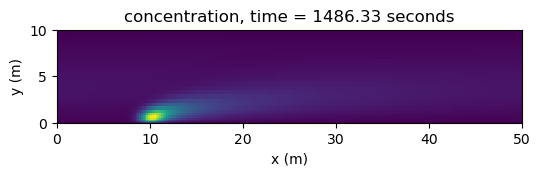

In [10]:
# create a figure and axes
fig = plt.figure(figsize=(6,6))

# Create arrays with the latitude and longitude coordinates for plotting using pcolor
from dedalus.extras import plot_tools
(X, Y) = plot_tools.quad_mesh(np.squeeze(x), np.squeeze(y))  

# Define an animation function
def drawframe(n):
    plt.clf()
    concentration = plt.pcolor(X, Y, c_save[n,:,:].T)
    # Specify the axis limits and labels
    plt.axis('square')
    plt.xlim(0, L)   
    plt.ylim(0, w)  
    plt.xlabel('x (m)')
    plt.ylabel('y (m)')
    plt.title('concentration, time = {0:.2f} seconds'.format(t_save[n]))
    return (concentration,)

from matplotlib import animation
# blit=True re-draws only the parts that have changed.
anim = animation.FuncAnimation(fig, drawframe, frames=len(t_save), interval=40, blit=True)

from IPython.display import HTML
HTML(anim.to_html5_video())

## 2.3 Student investigation
<a id='section2pt3'></a>
### Advective/diffusive timescales
In the boxes below, plot the pollution concentration at a few points as a function of time. Then vary the maximum flow speed and the diffusivity and explore how the pollution levels depend on these parameters. Using dimensional analysis, estimate the time needed for the pollution to reach the opposite side of the river. How far downstream of the source do you expect this to happen (assuming that the domain in the x-direction is infinite).

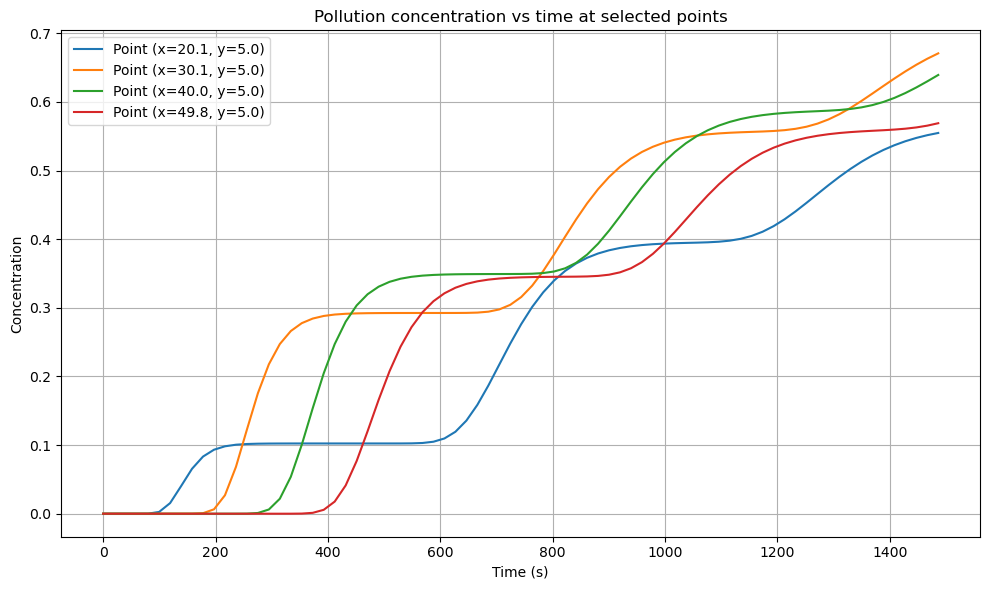

In [11]:
# Tracking different x-coordinates for constant y at y=w/2
points = [(103, 16), (154, 16), (205, 16), (255, 16)] 

plt.figure(figsize=(10,6))
for (i, j) in points:
    x_coord = (i / Nx) * L
    y_coord = (j / Ny) * w
    plt.plot(t_save, c_save[:, i, j], label=f'Point (x={x_coord:.1f}, y={y_coord:.1f})')

plt.xlabel('Time (s)')
plt.ylabel('Concentration')
plt.title('Pollution concentration vs time at selected points')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

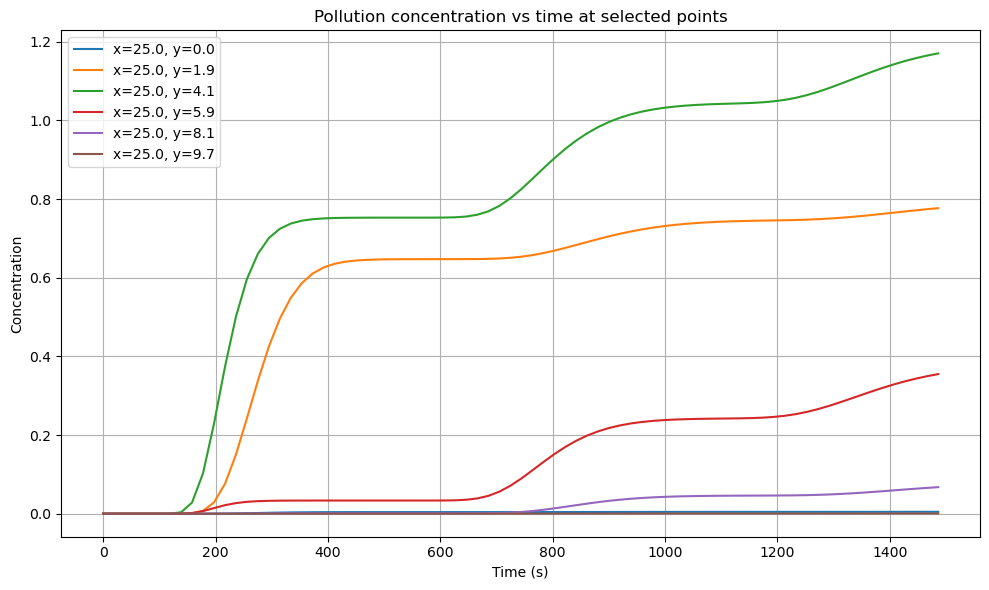

In [12]:
# Tracking different y-coordinates for constant x at x=L/2
points = [(128, 0), (128, 6), (128, 13), (128, 19), (128, 26), (128, 31)]

plt.figure(figsize=(10,6))
for (i, j) in points:
    x_coord = (i / Nx) * L
    y_coord = (j / Ny) * w
    plt.plot(t_save, c_save[:, i, j], label=f'x={x_coord:.1f}, y={y_coord:.1f}')

plt.xlabel('Time (s)')
plt.ylabel('Concentration')
plt.title('Pollution concentration vs time at selected points')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:
def pollution_solver(kappa = 1e-2, velocity = 0.1): 
    # Set parameters
    w = 10 # width of the river in m
    L = 50 # length of the river section to simulate
    S0 = 1 # amplitude of the pollution source term
    S_w = 1 # width of the source term in m
    S_x = 10 # center of the forcing in x
    S_y = 0 # center of the forcing in y
    S_t = 1 # forcing timescale
    U0 = velocity
    kappa = kappa

    # Numerical parameters
    Nx = 256 # number of gridoints in x
    Ny = 32 # number of gridpoints in y
    stop_sim_time=1500 # end time in seconds
    timestep = (L/Nx)/U0 # timestep in seconds, calculated from the CFL number

    # Bases and coordinates
    coords = dedalus.CartesianCoordinates('x', 'y')
    dist = dedalus.Distributor(coords, dtype=np.float64)
    xbasis = dedalus.RealFourier(coords['x'], size=Nx, bounds=(0, L), dealias=3/2)
    ybasis = dedalus.ChebyshevT(coords['y'], size=Ny, bounds=(0, w), dealias=3/2)
    x, y = dist.local_grids(xbasis, ybasis)
    ex, ey = coords.unit_vector_fields(dist) # x and y unit vectors

    # Fields
    c = dist.Field(name='c', bases=(xbasis,ybasis))
    u = dist.Field(name='u', bases=(xbasis,ybasis))
    tau_1 = dist.Field(name='tau_1', bases=xbasis)
    tau_2 = dist.Field(name='tau_2', bases=xbasis)

    # Specify the velocity field
    u['g'] = U0 * (1- (y - w/2)**2.0/(w/2)**2.0) # parabolic velocity profile

    # Substitutions
    lift_basis = ybasis.derivative_basis(1)
    lift = lambda A: dedalus.Lift(A, lift_basis, -1)
    grad_c = dedalus.grad(c) + ey*lift(tau_1)
    dx = lambda A: dedalus.Differentiate(A, coords['x'])

    S = dist.Field(name='u', bases=(xbasis,ybasis))
    S['g'] = S0*np.exp(-(x-S_x)**2.0/S_w**2.0-(y-S_y)**2.0/S_w**2.0)

    # Problem
    problem = dedalus.IVP([c, tau_1, tau_2], namespace=locals())
    problem.add_equation("dt(c) + u*dx(c) - kappa*div(grad_c) + lift(tau_2) = S/S_t")
    problem.add_equation("c(y=0) = 0")
    problem.add_equation("c(y=w) = 0")

    # Now, set the solver
    solver = problem.build_solver(dedalus.RK222)
    solver.stop_sim_time = stop_sim_time

    # Create an array to periodically save the concentration field for plotting later
    c.change_scales(1)
    c_save = [np.copy(c['g'])]; 

    t_save = [solver.sim_time]; # Save the initial condition and the initial time
    # Main loop
    try:
        logger.info('Starting main loop')
        while solver.proceed:
            solver.step(timestep)
            if (solver.iteration-1) % 10 == 0:
                logger.info('Iteration=%i, Time=%e, dt=%e' %(solver.iteration, solver.sim_time, timestep))
                c.change_scales(1)
                c_save.append(np.copy(c['g']))
                t_save.append(solver.sim_time)
    except:
        logger.error('Exception raised, triggering end of main loop.')
        raise
    finally:
        solver.log_stats()

    # Convert the variables to numpy arrays for allow array slicing
    c_save = np.array(c_save)

    return c_save, t_save

2025-11-12 08:41:01,184 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 0s, Remaining: 0s, Rate: 1.2e+01/s
2025-11-12 08:41:01,186 __main__ 0/1 INFO :: Starting main loop
2025-11-12 08:41:01,197 __main__ 0/1 INFO :: Iteration=1, Time=3.906250e-01, dt=3.906250e-01
2025-11-12 08:41:01,204 __main__ 0/1 INFO :: Iteration=11, Time=4.296875e+00, dt=3.906250e-01
2025-11-12 08:41:01,211 __main__ 0/1 INFO :: Iteration=21, Time=8.203125e+00, dt=3.906250e-01
2025-11-12 08:41:01,218 __main__ 0/1 INFO :: Iteration=31, Time=1.210938e+01, dt=3.906250e-01
2025-11-12 08:41:01,225 __main__ 0/1 INFO :: Iteration=41, Time=1.601562e+01, dt=3.906250e-01
2025-11-12 08:41:01,232 __main__ 0/1 INFO :: Iteration=51, Time=1.992188e+01, dt=3.906250e-01
2025-11-12 08:41:01,239 __main__ 0/1 INFO :: Iteration=61, Time=2.382812e+01, dt=3.906250e-01
2025-11-12 08:41:01,246 __main__ 0/1 INFO :: Iteration=71, Time=2.773438e+01, dt=3.906250e-01
2025-11-12 08:41:01,253 __main__ 0/1 INFO :: Iteratio

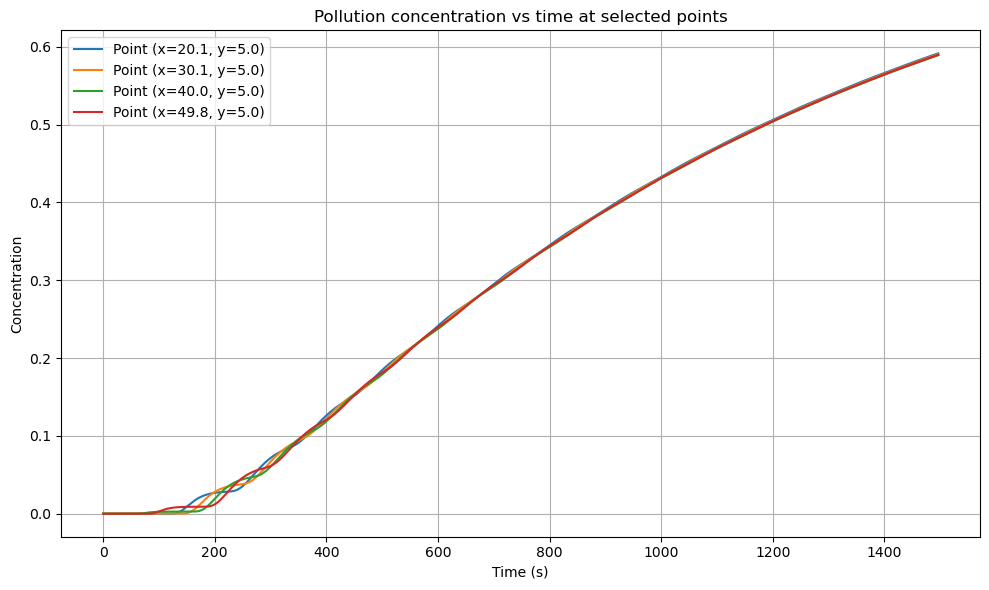

In [14]:
c_save, t_save = pollution_solver(velocity = 0.5)
points = [(103, 16), (154, 16), (205, 16), (255, 16)] 

plt.figure(figsize=(10,6))
for (i, j) in points:
    x_coord = (i / Nx) * L
    y_coord = (j / Ny) * w
    plt.plot(t_save, c_save[:, i, j], label=f'Point (x={x_coord:.1f}, y={y_coord:.1f})')
    
plt.xlabel('Time (s)')
plt.ylabel('Concentration')
plt.title('Pollution concentration vs time at selected points')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Varying maximum flow speed and diffusivity

*Varying Maximum Flow Speed*

2025-11-12 08:41:04,099 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 0s, Remaining: 0s, Rate: 1.2e+01/s
2025-11-12 08:41:04,100 __main__ 0/1 INFO :: Starting main loop
2025-11-12 08:41:04,111 __main__ 0/1 INFO :: Iteration=1, Time=7.812500e+00, dt=7.812500e+00
2025-11-12 08:41:04,118 __main__ 0/1 INFO :: Iteration=11, Time=8.593750e+01, dt=7.812500e+00
2025-11-12 08:41:04,125 __main__ 0/1 INFO :: Iteration=21, Time=1.640625e+02, dt=7.812500e+00
2025-11-12 08:41:04,132 __main__ 0/1 INFO :: Iteration=31, Time=2.421875e+02, dt=7.812500e+00
2025-11-12 08:41:04,139 __main__ 0/1 INFO :: Iteration=41, Time=3.203125e+02, dt=7.812500e+00
2025-11-12 08:41:04,146 __main__ 0/1 INFO :: Iteration=51, Time=3.984375e+02, dt=7.812500e+00
2025-11-12 08:41:04,153 __main__ 0/1 INFO :: Iteration=61, Time=4.765625e+02, dt=7.812500e+00
2025-11-12 08:41:04,160 __main__ 0/1 INFO :: Iteration=71, Time=5.546875e+02, dt=7.812500e+00
2025-11-12 08:41:04,167 __main__ 0/1 INFO :: Iteratio

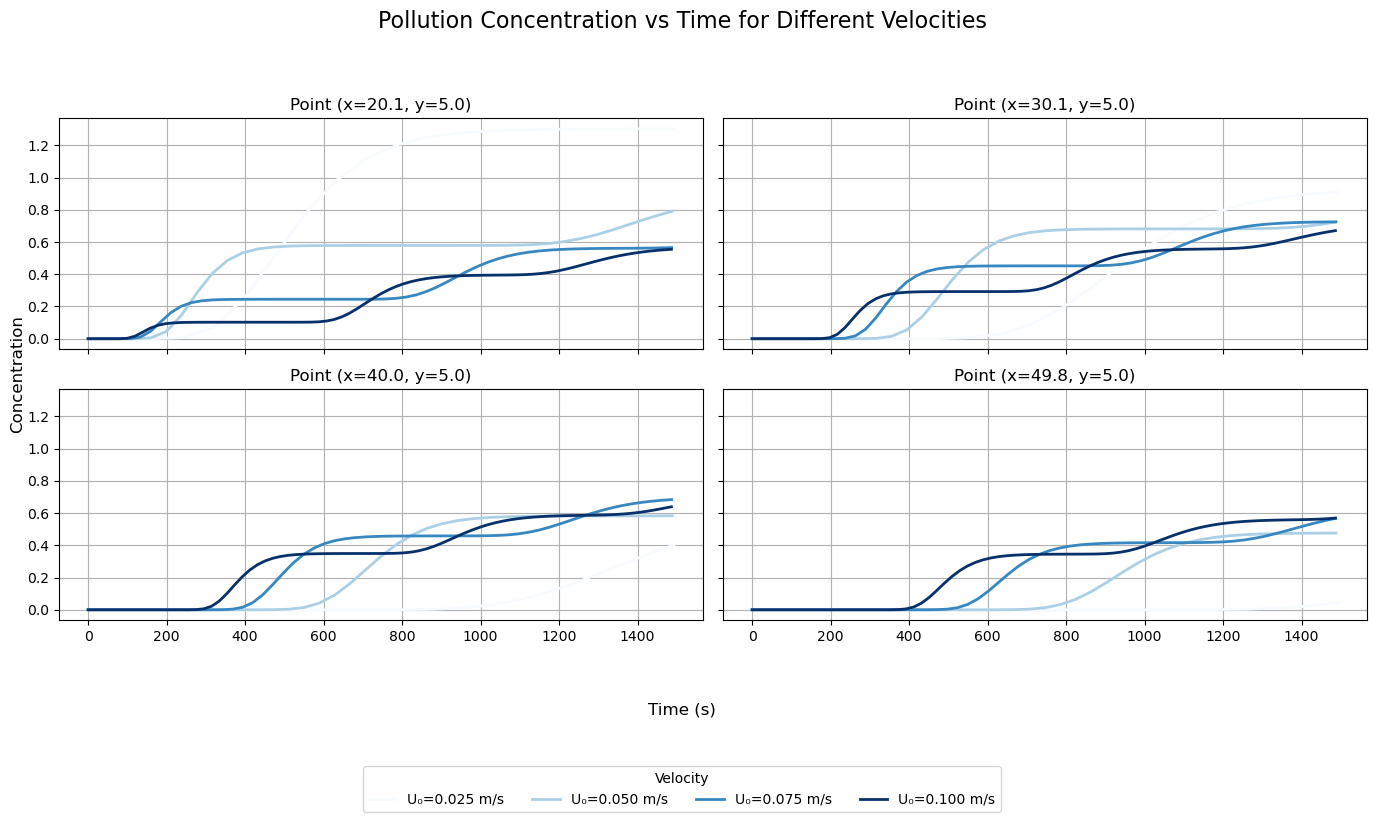

In [15]:
import matplotlib.cm as cm
import matplotlib as mpl
import matplotlib.pyplot as plt

velocities = [0.025, 0.05, 0.075, 0.1]   # m/s 
points = [(103, 16), (154, 16), (205, 16), (255, 16)] 

# Run solver once per velocity
results = {}
for v in velocities:
    c_save, t_save = pollution_solver(velocity=v)
    results[v] = (c_save, t_save)

# Colormap: lighter for smaller v, darker for larger v
norm = mpl.colors.Normalize(vmin=min(velocities), vmax=max(velocities))
cmap = cm.Blues

fig, axs = plt.subplots(2, 2, figsize=(14, 7), sharex=True, sharey=True)

for ax, (i, j) in zip(axs.flat, points):
    x_coord = (i / Nx) * L
    y_coord = (j / Ny) * w
    for v in velocities:
        c_save, t_save = results[v]
        ax.plot(t_save, c_save[:, i, j],
                color=cmap(norm(v)), lw=2, label=f"U₀={v:.3f} m/s")
    ax.set_title(f'Point (x={x_coord:.1f}, y={y_coord:.1f})')
    ax.grid(True)

# Shared axis labels
fig.supxlabel("Time (s)")
fig.supylabel("Concentration")

# Add a figure title
fig.suptitle("Pollution Concentration vs Time for Different Velocities",
             fontsize=16, y=1.02)

# Create a shared legend below the plots (does not block labels)
handles = [mpl.lines.Line2D([], [], color=cmap(norm(v)), lw=2, label=f"U₀={v:.3f} m/s")
           for v in velocities]
fig.legend(handles=handles,
           loc="upper center", bbox_to_anchor=(0.5, -0.05),
           ncol=len(velocities), frameon=True, title="Velocity")

# Adjust layout so title and legend fit
plt.tight_layout(rect=[0, 0.05, 1, 0.97])  
plt.show()

2025-11-12 08:41:06,106 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 0s, Remaining: 0s, Rate: 1.2e+01/s
2025-11-12 08:41:06,107 __main__ 0/1 INFO :: Starting main loop
2025-11-12 08:41:06,118 __main__ 0/1 INFO :: Iteration=1, Time=7.812500e+00, dt=7.812500e+00
2025-11-12 08:41:06,125 __main__ 0/1 INFO :: Iteration=11, Time=8.593750e+01, dt=7.812500e+00
2025-11-12 08:41:06,132 __main__ 0/1 INFO :: Iteration=21, Time=1.640625e+02, dt=7.812500e+00
2025-11-12 08:41:06,139 __main__ 0/1 INFO :: Iteration=31, Time=2.421875e+02, dt=7.812500e+00
2025-11-12 08:41:06,146 __main__ 0/1 INFO :: Iteration=41, Time=3.203125e+02, dt=7.812500e+00
2025-11-12 08:41:06,153 __main__ 0/1 INFO :: Iteration=51, Time=3.984375e+02, dt=7.812500e+00
2025-11-12 08:41:06,160 __main__ 0/1 INFO :: Iteration=61, Time=4.765625e+02, dt=7.812500e+00
2025-11-12 08:41:06,167 __main__ 0/1 INFO :: Iteration=71, Time=5.546875e+02, dt=7.812500e+00
2025-11-12 08:41:06,173 __main__ 0/1 INFO :: Iteratio

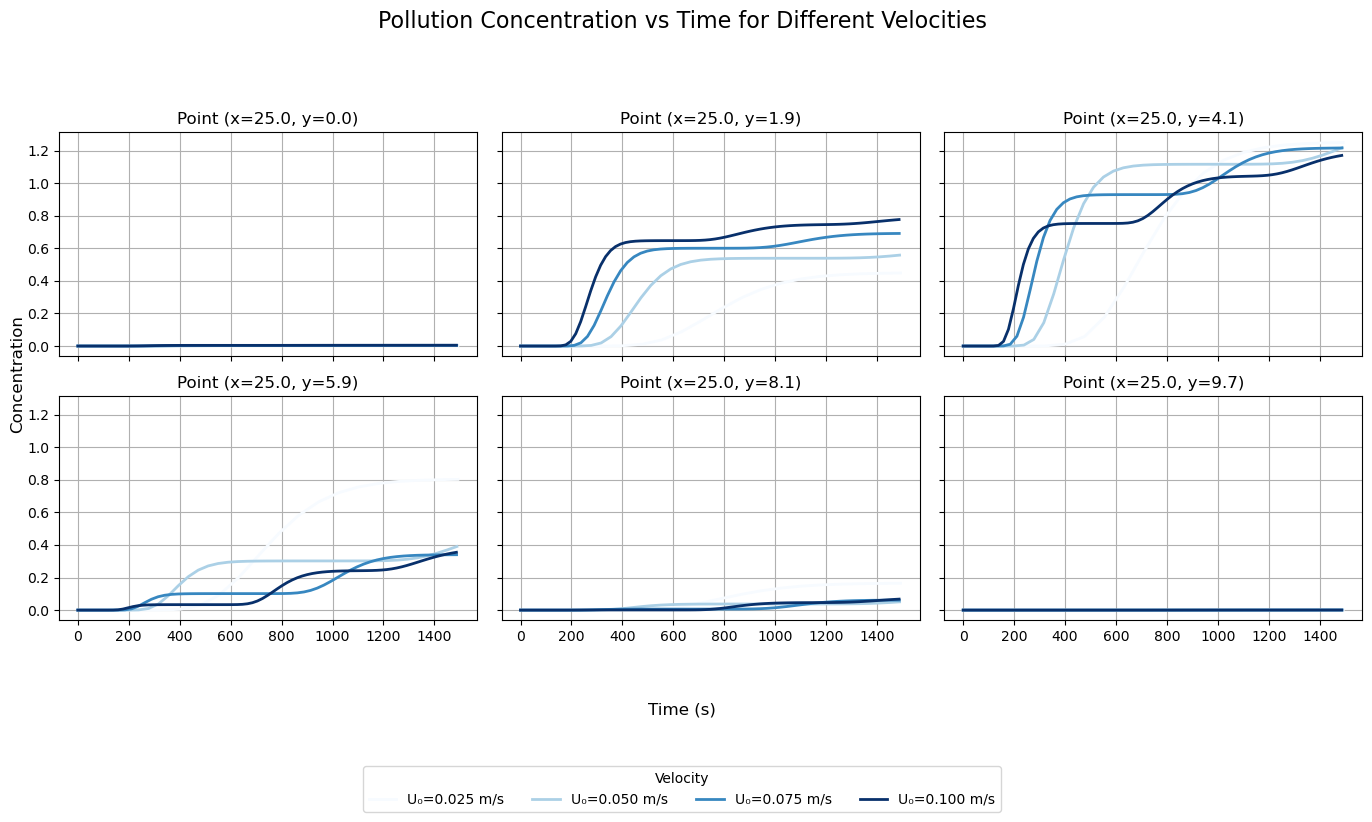

In [16]:
import matplotlib.cm as cm
import matplotlib as mpl
import matplotlib.pyplot as plt

velocities = [0.025, 0.05, 0.075, 0.1]   # m/s 
points = [(128, 0), (128, 6), (128, 13), (128, 19), (128, 26), (128, 31)]

# Run solver once per velocity
results = {}
for v in velocities:
    c_save, t_save = pollution_solver(velocity=v)
    results[v] = (c_save, t_save)

# Colormap: lighter for smaller v, darker for larger v
norm = mpl.colors.Normalize(vmin=min(velocities), vmax=max(velocities))
cmap = cm.Blues

fig, axs = plt.subplots(2, 3, figsize=(14, 7), sharex=True, sharey=True)

for ax, (i, j) in zip(axs.flat, points):
    x_coord = (i / Nx) * L
    y_coord = (j / Ny) * w
    for v in velocities:
        c_save, t_save = results[v]
        ax.plot(t_save, c_save[:, i, j],
                color=cmap(norm(v)), lw=2, label=f"U₀={v:.3f} m/s")
    ax.set_title(f'Point (x={x_coord:.1f}, y={y_coord:.1f})')
    ax.grid(True)

# Shared axis labels
fig.supxlabel("Time (s)")
fig.supylabel("Concentration")

# Add a main title
fig.suptitle("Pollution Concentration vs Time for Different Velocities",
             fontsize=16, y=1.02)

# Shared legend (placed below the figure so it doesn’t overlap the x-label)
handles = [mpl.lines.Line2D([], [], color=cmap(norm(v)), lw=2, label=f"U₀={v:.3f} m/s")
           for v in velocities]
fig.legend(handles=handles,
           loc="upper center", bbox_to_anchor=(0.5, -0.05),
           ncol=len(velocities), frameon=True, title="Velocity")

# Adjust layout to fit everything neatly
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

**ANSWER:** The first figure shows the meridional (downstream) flow at a few points downstream of the source, while the second figure shows the cross-sectional concentration profiles at different positions across the river. These figures confirm that pollutants arrive earlier at higher flow velocities, as expected. However, we also observe that once the pollutants reach an x-coordinate not too far downstream from the source, the pollutant concentrations are higher for lower velocities. This occurs because at slower velocities, advection is weaker and pollutants accumulate locally rather than being quickly advected away. Farther downstream, the trend reverses: pollutant levels become higher for faster velocities. At low velocities, diffusion dominates and pollutants spread out vertically and laterally before reaching the end of the domain, leading to lower concentrations at any given downstream location. In contrast, at higher velocities, advection transports the tracer downstream faster than it can diffuse vertically, so the plume remains more concentrated and less well-mixed across the river.

2025-11-12 08:41:08,190 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 0s, Remaining: 0s, Rate: 1.2e+01/s
2025-11-12 08:41:08,191 __main__ 0/1 INFO :: Starting main loop
2025-11-12 08:41:08,202 __main__ 0/1 INFO :: Iteration=1, Time=1.953125e+00, dt=1.953125e+00
2025-11-12 08:41:08,209 __main__ 0/1 INFO :: Iteration=11, Time=2.148438e+01, dt=1.953125e+00
2025-11-12 08:41:08,216 __main__ 0/1 INFO :: Iteration=21, Time=4.101562e+01, dt=1.953125e+00
2025-11-12 08:41:08,224 __main__ 0/1 INFO :: Iteration=31, Time=6.054688e+01, dt=1.953125e+00
2025-11-12 08:41:08,231 __main__ 0/1 INFO :: Iteration=41, Time=8.007812e+01, dt=1.953125e+00
2025-11-12 08:41:08,238 __main__ 0/1 INFO :: Iteration=51, Time=9.960938e+01, dt=1.953125e+00
2025-11-12 08:41:08,249 __main__ 0/1 INFO :: Iteration=61, Time=1.191406e+02, dt=1.953125e+00
2025-11-12 08:41:08,258 __main__ 0/1 INFO :: Iteration=71, Time=1.386719e+02, dt=1.953125e+00
2025-11-12 08:41:08,265 __main__ 0/1 INFO :: Iteratio

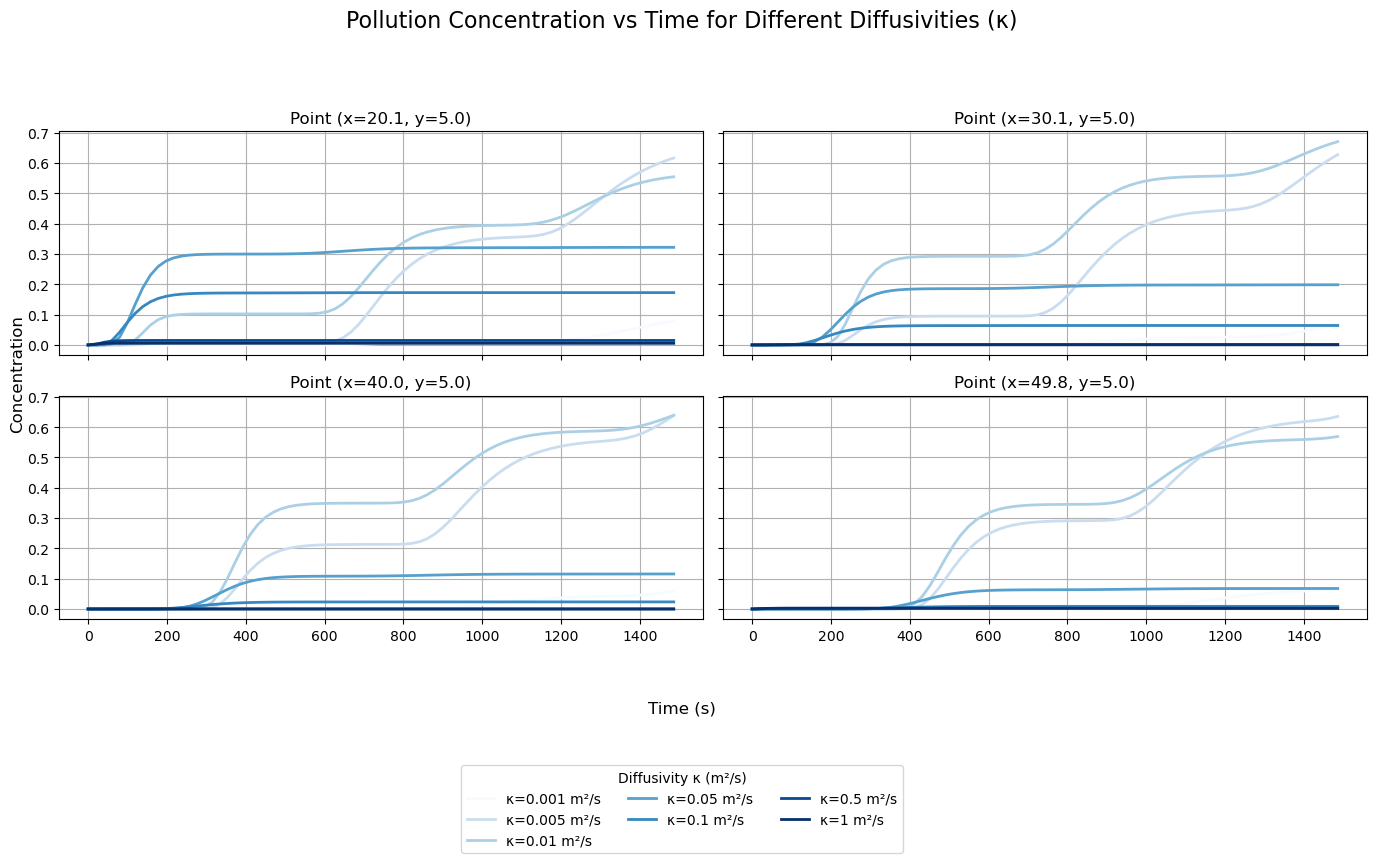

In [17]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib as mpl
from matplotlib.colors import LogNorm

kappas = [1e-3, 5e-3, 1e-2, 5e-2, 0.1, 0.5, 1.0] 
points = [(103, 16), (154, 16), (205, 16), (255, 16)] 

# Run solver once per κ
results = {}
for kappa_value in kappas:
    c_save, t_save = pollution_solver(kappa=kappa_value)
    results[kappa_value] = (c_save, t_save)

# Colormap: lighter for smaller κ, darker for larger κ (log scale)
norm = LogNorm(vmin=min(kappas), vmax=max(kappas))
cmap = cm.Blues

fig, axs = plt.subplots(2, 2, figsize=(14, 7), sharex=True, sharey=True)

for ax, (i, j) in zip(axs.flat, points):
    x_coord = (i / Nx) * L
    y_coord = (j / Ny) * w
    for kappa_value in kappas:
        c_save, t_save = results[kappa_value]
        ax.plot(
            t_save, c_save[:, i, j],
            color=cmap(norm(kappa_value)), lw=2,
            label=f"κ={kappa_value:.3g} m²/s"
        )
    ax.set_title(f'Point (x={x_coord:.1f}, y={y_coord:.1f})')
    ax.grid(True)

# Shared axis labels
fig.supxlabel("Time (s)")
fig.supylabel("Concentration")

# Add main figure title
fig.suptitle("Pollution Concentration vs Time for Different Diffusivities (κ)",
             fontsize=16, y=1.02)

# Shared legend (below the figure, avoids blocking labels)
handles = [
    mpl.lines.Line2D([], [], color=cmap(norm(kv)), lw=2, label=f"κ={kv:.3g} m²/s")
    for kv in kappas
]
fig.legend(
    handles=handles,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=len(kappas)//2,
    frameon=True,
    title="Diffusivity κ (m²/s)"
)

# Adjust layout so everything fits cleanly
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

2025-11-12 08:41:12,976 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 0s, Remaining: 0s, Rate: 1.2e+01/s
2025-11-12 08:41:12,977 __main__ 0/1 INFO :: Starting main loop
2025-11-12 08:41:12,987 __main__ 0/1 INFO :: Iteration=1, Time=1.953125e+00, dt=1.953125e+00
2025-11-12 08:41:12,995 __main__ 0/1 INFO :: Iteration=11, Time=2.148438e+01, dt=1.953125e+00
2025-11-12 08:41:13,002 __main__ 0/1 INFO :: Iteration=21, Time=4.101562e+01, dt=1.953125e+00
2025-11-12 08:41:13,009 __main__ 0/1 INFO :: Iteration=31, Time=6.054688e+01, dt=1.953125e+00
2025-11-12 08:41:13,016 __main__ 0/1 INFO :: Iteration=41, Time=8.007812e+01, dt=1.953125e+00
2025-11-12 08:41:13,023 __main__ 0/1 INFO :: Iteration=51, Time=9.960938e+01, dt=1.953125e+00
2025-11-12 08:41:13,030 __main__ 0/1 INFO :: Iteration=61, Time=1.191406e+02, dt=1.953125e+00
2025-11-12 08:41:13,037 __main__ 0/1 INFO :: Iteration=71, Time=1.386719e+02, dt=1.953125e+00
2025-11-12 08:41:13,044 __main__ 0/1 INFO :: Iteratio

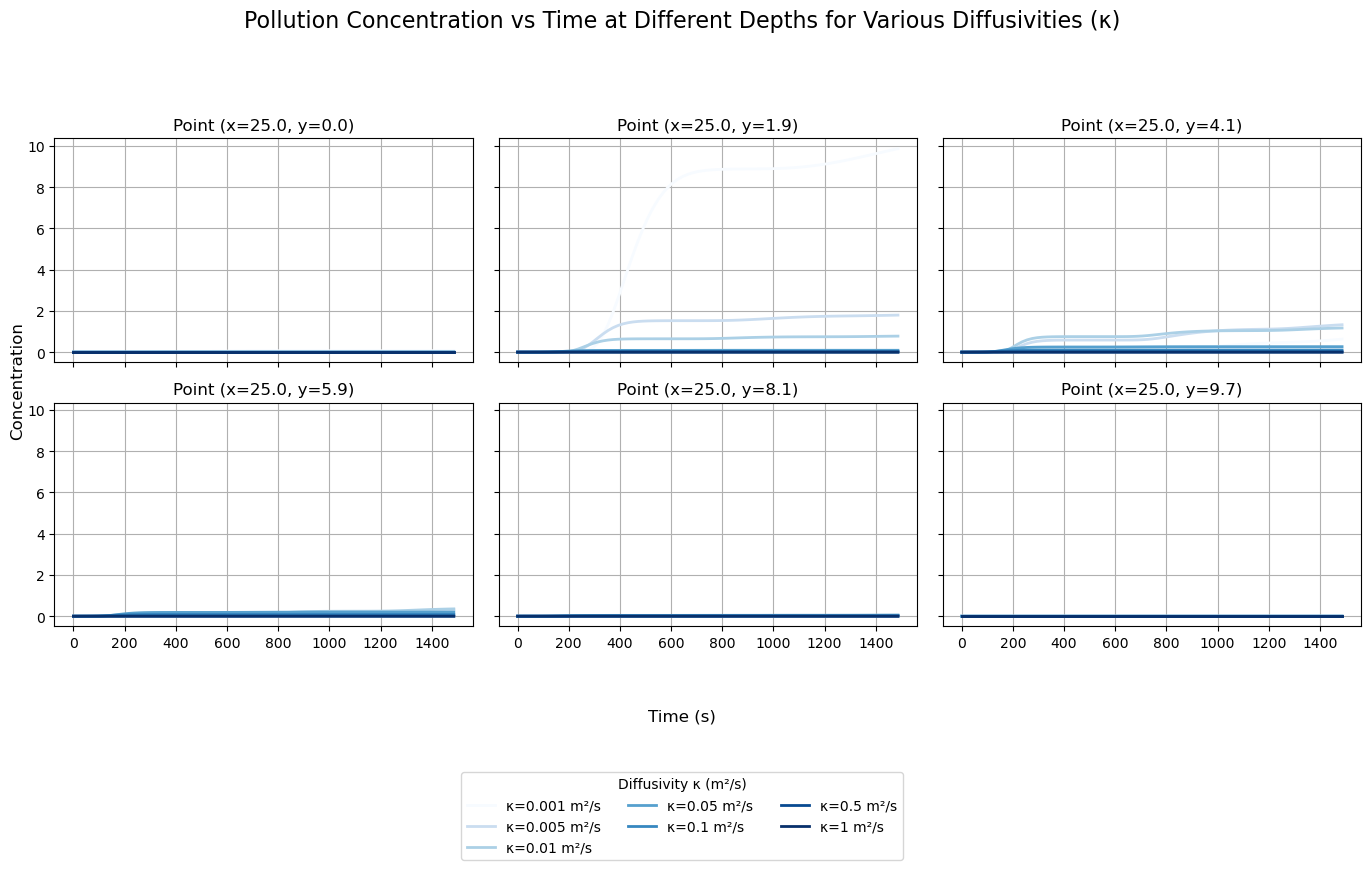

In [18]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib as mpl
from matplotlib.colors import LogNorm

kappas = [1e-3, 5e-3, 1e-2, 5e-2, 0.1, 0.5, 1.0] 
points = [(128, 0), (128, 6), (128, 13), (128, 19), (128, 26), (128, 31)]

results = {}
for kappa_value in kappas:
    c_save, t_save = pollution_solver(kappa=kappa_value)
    results[kappa_value] = (c_save, t_save)

# Colormap: lighter for smaller κ, darker for larger κ (log scale)
norm = LogNorm(vmin=min(kappas), vmax=max(kappas))
cmap = cm.Blues

fig, axs = plt.subplots(2, 3, figsize=(14, 7), sharex=True, sharey=True)

for ax, (i, j) in zip(axs.flat, points):
    x_coord = (i / Nx) * L
    y_coord = (j / Ny) * w
    for kappa_value in kappas:
        c_save, t_save = results[kappa_value]
        ax.plot(
            t_save,
            c_save[:, i, j],
            color=cmap(norm(kappa_value)),
            lw=2,
            label=f"κ={kappa_value:.3g} m²/s"
        )
    ax.set_title(f'Point (x={x_coord:.1f}, y={y_coord:.1f})')
    ax.grid(True)

# Shared axis labels
fig.supxlabel("Time (s)")
fig.supylabel("Concentration")

# Add main title
fig.suptitle(
    "Pollution Concentration vs Time at Different Depths for Various Diffusivities (κ)",
    fontsize=16, y=1.03
)

# Shared legend below the figure
handles = [
    mpl.lines.Line2D([], [], color=cmap(norm(kv)), lw=2, label=f"κ={kv:.3g} m²/s")
    for kv in kappas
]
fig.legend(
    handles=handles,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=len(kappas)//2,
    frameon=True,
    title="Diffusivity κ (m²/s)"
)

# Adjust layout to fit everything
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

**ANSWER:** Similar to above, the two plots show how the concentration profiles evolve for different values of diffusivity at selected downstream (meridional) and cross-sectional points. For a fixed flow velocity, increasing the diffusivity generally reduces the local accumulation of pollutants because diffusion acts to spread the concentration more evenly throughout the domain. In the first figure (the meridional concentration profiles), we observe a non-monotonic behavior. At very low diffusivities, the concentration remains low for a longer time than for moderate diffusivities because the pollutants stay tightly confined near the source and are advected downstream before they can spread laterally (across the river). As diffusivity increases to moderate values, diffusion becomes strong enough to distribute pollutants more effectively without completely diluting them, leading to a temporary increase in observed concentration at specific downstream locations. However, at even larger diffusivities, the tracer becomes too well mixed, and concentration gradients flatten, causing the local concentration levels to decrease again. The second figure (cross-sectional profiles) illustrates how the width of the plume changes with diffusivity. For small kappa, the tracer remains confined near the center of the flow, forming a narrow and concentrated plume. As diffusivity increases, the pollutant diffuses too rapidly that concentrations remain consistently low throughout.

As for the dimensional analysis, we have

$$ \frac{\partial c}{\partial t} + u(y)\frac{\partial c}{\partial x} = \kappa \nabla^2 c + S(x,y).$$

Because x is infinite in the domain, we have the characteristic length scale L for x being much larger than the characteristic length scale W for y. In other words $L >> W.$ Let C be the characteristic scale for concentration. As a result, $\frac{\kappa C}{L^2} << \frac{\kappa C}{W^2}.$ This means $\frac{C}{T}$ scales with $\frac{\kappa C}{W^2}.$ Hence the characteristic timescale T scales with $\frac{W^2}{\kappa}.$ To then get how far downstream this is, we note that the depth-averaged (cross-stream averaged) velocity is given by 
$$\bar{U} = \frac{1}{W} \int_0^W U(y) \, dy.$$

$$\bar{U} = \frac{U_0}{W} \int_0^W \left[ 1 - \left( \frac{y - \tfrac{W}{2}}{\tfrac{W}{2}} \right)^2 \right] dy.$$

$$\bar{U} = U_0 \left[ \frac{1}{W} \int_0^W 1 \, dy - \frac{1}{W} \int_0^W \frac{(y - \tfrac{W}{2})^2}{(\tfrac{W}{2})^2} \, dy \right].$$

$$\int_0^W (y - \tfrac{W}{2})^2 \, dy = \left[ \frac{(y - \tfrac{W}{2})^3}{3} \right]_0^W = \frac{W^3}{12}.$$

$$\frac{1}{W} \int_0^W \frac{(y - \tfrac{W}{2})^2}{(\tfrac{W}{2})^2} \, dy = \frac{1}{W} \cdot  \frac{W^3 / 12}{(W/2)^2} = \frac{1}{W} \cdot \frac{W^3 / 12}{W^2 / 4} = \frac{1}{3}.$$

$$ \bar{U} = U_0 \left( 1 - \frac{1}{3} \right) = \frac{2}{3} U_0.$$
Hence, the depth-averaged velocity is.
$$\bar{U} = \tfrac{2}{3} U_0.$$

Since the downstream x-coordinate at which the tracer reaches across the river is the velocity times the time, we have

$$X \sim \frac{2 U_0}{3} \frac{W^2}{\kappa} $$

### Turbulent diffusion
In a turbulent flow, tracers will be transported by the turbulent eddies. A common way to model this is to introduce a turbulent diffusivity, $\kappa_T\sim u*l$, where $u$ and $l$ are characteristic velocity and length scales associated with the turbulent eddies.

To explore this effect, create a Dedalus script that includes advection by $u$ and $v$ (the $x$ and $y$ components of the velocity). Then, use the same velocity field as above for $u$ and add to that a fluctuating velocity field that of the form

$$ u=u_0 cos(kx)cos(ky), \quad v=u_0 sin(kx)sin(ky) $$

where $k$ is the wavenumber associated with the velocity fluctuations and $u_0$ is the amplitude of the fluctuations. Note that $k$ should be set to give an integer number of wavelengths in the $x$ and $y$ directions. Vary both $u_0$ and $k$ and study how quicky the tracer is transported across the river. Qualitatively compare this with the expectation based on the hypothesis of turbulent diffusion.

New governing equation:
$$ \frac{\partial c}{\partial t} + u(x,y)\frac{\partial c}{\partial x} + v(x,y)\frac{\partial c}{\partial y} = \kappa \nabla^2 c + S(x,y) $$

*Running one case*

Note that we extend the runtime and domain in order to provide better visualizations.

In [19]:
"""
Script to solve the time-dependent advection/diffusion equation
"""

import numpy as np
import matplotlib.pyplot as plt
import dedalus.public as dedalus
import logging
logger = logging.getLogger(__name__)

# Set parameters
U0 = 0.1 # maximum current speed in m/s
w = 20 # width of the river in m
L = 200 # length of the river section to simulate
kappa = 1e-2 # diffusivity in m^2/s
S0 = 1 # amplitude of the pollution source term
S_w = 1 # width of the source term in m
S_x = 10 # center of the forcing in x
S_y = 0 # center of the forcing in y
S_t = 1 # forcing timescale

u0 = 0.025  # amplitude of the fluctuation
nx = 1     # integer number of wavelengths in x
ny = 1    # integer number of wavelengths in y

# Numerical parameters
Nx = 512 # number of gridoints in x
Ny = 64 # number of gridpoints in y
stop_sim_time= 5000 # end time in seconds
timestep = (L/Nx)/U0 # timestep in seconds, calculated from the CFL number

# Bases and coordinates
coords = dedalus.CartesianCoordinates('x', 'y')
dist = dedalus.Distributor(coords, dtype=np.float64)
xbasis = dedalus.RealFourier(coords['x'], size=Nx, bounds=(0, L), dealias=3/2)
ybasis = dedalus.ChebyshevT(coords['y'], size=Ny, bounds=(0, w), dealias=3/2)
x, y = dist.local_grids(xbasis, ybasis)
ex, ey = coords.unit_vector_fields(dist) # x and y unit vectors

# Fields
c = dist.Field(name='c', bases=(xbasis, ybasis))
u = dist.Field(name='u', bases=(xbasis, ybasis))
v = dist.Field(name='v', bases=(xbasis, ybasis))
tau_1 = dist.Field(name='tau_1', bases=xbasis)
tau_2 = dist.Field(name='tau_2', bases=xbasis)

# Wavenumbers that give integer wavelengths
kx = 2*np.pi*nx / L  
ky = 2*np.pi*ny / w 

# Specify the velocity field
u['g'] = U0 * (1- (y - w/2)**2.0/(w/2)**2.0) + u0 * np.cos(kx*x) * np.cos(ky*y)
v['g'] = u0 * np.sin(kx * x) * np.sin(ky * y)

# Substitutions
lift_basis = ybasis.derivative_basis(1)
lift = lambda A: dedalus.Lift(A, lift_basis, -1)
grad_c = dedalus.grad(c) + ey*lift(tau_1)
dx = lambda A: dedalus.Differentiate(A, coords['x'])
cy = grad_c @ ey

# Source
S = dist.Field(name='u', bases=(xbasis,ybasis))
S['g'] = S0*np.exp(-(x-S_x)**2.0/S_w**2.0-(y-S_y)**2.0/S_w**2.0)

# Problem
problem = dedalus.IVP([c, tau_1, tau_2], namespace=locals())
problem.add_equation("dt(c) + u*dx(c) + v*cy - kappa*div(grad_c) + lift(tau_2) = S/S_t")
problem.add_equation("c(y=0) = 0")
problem.add_equation("c(y=w) = 0")

# Now, set the solver
solver = problem.build_solver(dedalus.RK222)
solver.stop_sim_time = stop_sim_time

# Create an array to periodically save the concentration field for plotting later
c.change_scales(1)
c_save = [np.copy(c['g'])]; 

t_save = [solver.sim_time]; # Save the initial condition and the initial time
# Main loop
try:
    logger.info('Starting main loop')
    while solver.proceed:
        solver.step(timestep)
        if (solver.iteration-1) % 10 == 0:
            logger.info('Iteration=%i, Time=%e, dt=%e' %(solver.iteration, solver.sim_time, timestep))
            c.change_scales(1)
            c_save.append(np.copy(c['g']))
            t_save.append(solver.sim_time)
except:
    logger.error('Exception raised, triggering end of main loop.')
    raise
finally:
    solver.log_stats()

# Convert the variables to numpy arrays for allow array slicing
c_save = np.array(c_save)

2025-11-12 08:41:18,653 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 1s, Remaining: 0s, Rate: 1.8e+00/s
2025-11-12 08:41:18,655 __main__ 0/1 INFO :: Starting main loop
2025-11-12 08:41:21,063 __main__ 0/1 INFO :: Iteration=1, Time=3.906250e+00, dt=3.906250e+00
2025-11-12 08:41:21,227 __main__ 0/1 INFO :: Iteration=11, Time=4.296875e+01, dt=3.906250e+00
2025-11-12 08:41:21,384 __main__ 0/1 INFO :: Iteration=21, Time=8.203125e+01, dt=3.906250e+00
2025-11-12 08:41:21,539 __main__ 0/1 INFO :: Iteration=31, Time=1.210938e+02, dt=3.906250e+00
2025-11-12 08:41:21,695 __main__ 0/1 INFO :: Iteration=41, Time=1.601562e+02, dt=3.906250e+00
2025-11-12 08:41:21,849 __main__ 0/1 INFO :: Iteration=51, Time=1.992188e+02, dt=3.906250e+00
2025-11-12 08:41:22,004 __main__ 0/1 INFO :: Iteration=61, Time=2.382812e+02, dt=3.906250e+00
2025-11-12 08:41:22,163 __main__ 0/1 INFO :: Iteration=71, Time=2.773438e+02, dt=3.906250e+00
2025-11-12 08:41:22,325 __main__ 0/1 INFO :: Iteratio

2025-11-12 08:41:41,642 matplotlib.animation 0/1 INFO :: Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
2025-11-12 08:41:41,643 matplotlib.animation 0/1 INFO :: MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 600x600 -pix_fmt rgba -framerate 25.0 -i pipe: -vcodec h264 -pix_fmt yuv420p -y /var/folders/rp/zp_9g6fs2nz5lbnfxvt4jm0c0000gn/T/tmpxnbj0n35/temp.m4v


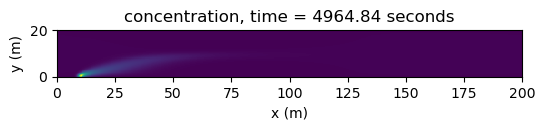

In [20]:
# create a figure and axes
fig = plt.figure(figsize=(6,6))

# Create arrays with the latitude and longitude coordinates for plotting using pcolor
from dedalus.extras import plot_tools
(X, Y) = plot_tools.quad_mesh(np.squeeze(x), np.squeeze(y))  

# Define an animation function
def drawframe(n):
    plt.clf()
    concentration = plt.pcolor(X, Y, c_save[n,:,:].T)
    # Specify the axis limits and labels
    plt.axis('square')
    plt.xlim(0, L)   
    plt.ylim(0, w)  
    plt.xlabel('x (m)')
    plt.ylabel('y (m)')
    plt.title('concentration, time = {0:.2f} seconds'.format(t_save[n]))
    return (concentration,)

from matplotlib import animation
# blit=True re-draws only the parts that have changed.
anim = animation.FuncAnimation(fig, drawframe, frames=len(t_save), interval=40, blit=True)

from IPython.display import HTML
HTML(anim.to_html5_video())

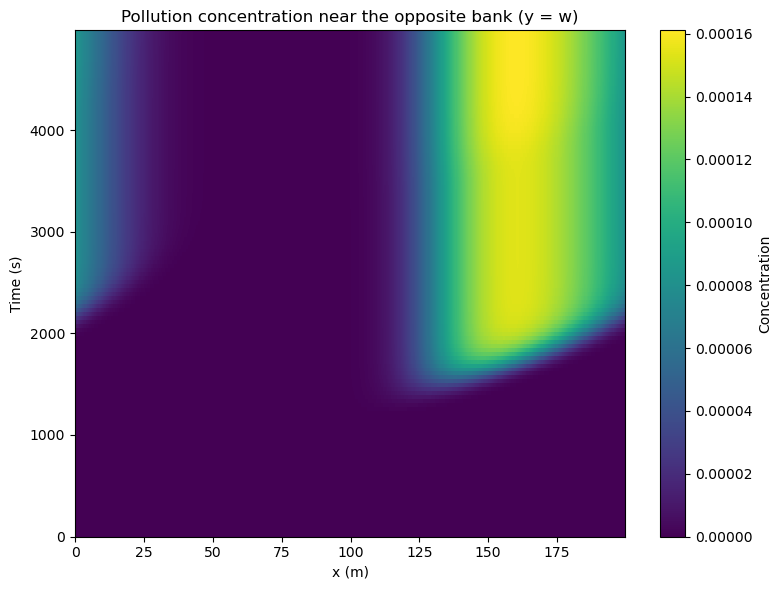

In [21]:
# c_save has shape (Nt, Nx, Ny)
# y=-1 is the top boundary (y = w)

c_last_y = c_save[:, :, -1]  # shape (Nt, Nx)

# Make a 2D image: x vs t
plt.figure(figsize=(8, 6))
plt.pcolormesh(x[:, 0], t_save, c_last_y, shading='auto', cmap='viridis')
plt.xlabel("x (m)")
plt.ylabel("Time (s)")
plt.title("Pollution concentration near the opposite bank (y = w)")
plt.colorbar(label="Concentration")
plt.tight_layout()
plt.show()

**Iterating through different values of u0**

2025-11-12 08:42:14,313 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 0s, Remaining: 0s, Rate: 4.0e+00/s
2025-11-12 08:42:14,315 __main__ 0/1 INFO :: Run: u0=0.000, nx=1, ny=1, dt=3.906e+00
2025-11-12 08:42:17,334 solvers 0/1 INFO :: Simulation stop time reached.
2025-11-12 08:42:17,335 solvers 0/1 INFO :: Final iteration: 1280
2025-11-12 08:42:17,335 solvers 0/1 INFO :: Final sim time: 5000.0
2025-11-12 08:42:17,335 solvers 0/1 INFO :: Setup time (init - iter 0): 0.2903 sec
2025-11-12 08:42:17,335 solvers 0/1 INFO :: Warmup time (iter 0-10): 0.07058 sec
2025-11-12 08:42:17,336 solvers 0/1 INFO :: Run time (iter 10-end): 2.949 sec
2025-11-12 08:42:17,336 solvers 0/1 INFO :: CPU time (iter 10-end): 0.0008192 cpu-hr
2025-11-12 08:42:17,336 solvers 0/1 INFO :: Speed: 2.905e+07 mode-stages/cpu-sec
2025-11-12 08:42:17,911 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 1s, Remaining: 0s, Rate: 1.9e+00/s
2025-11-12 08:42:17,913 __main__ 0/1

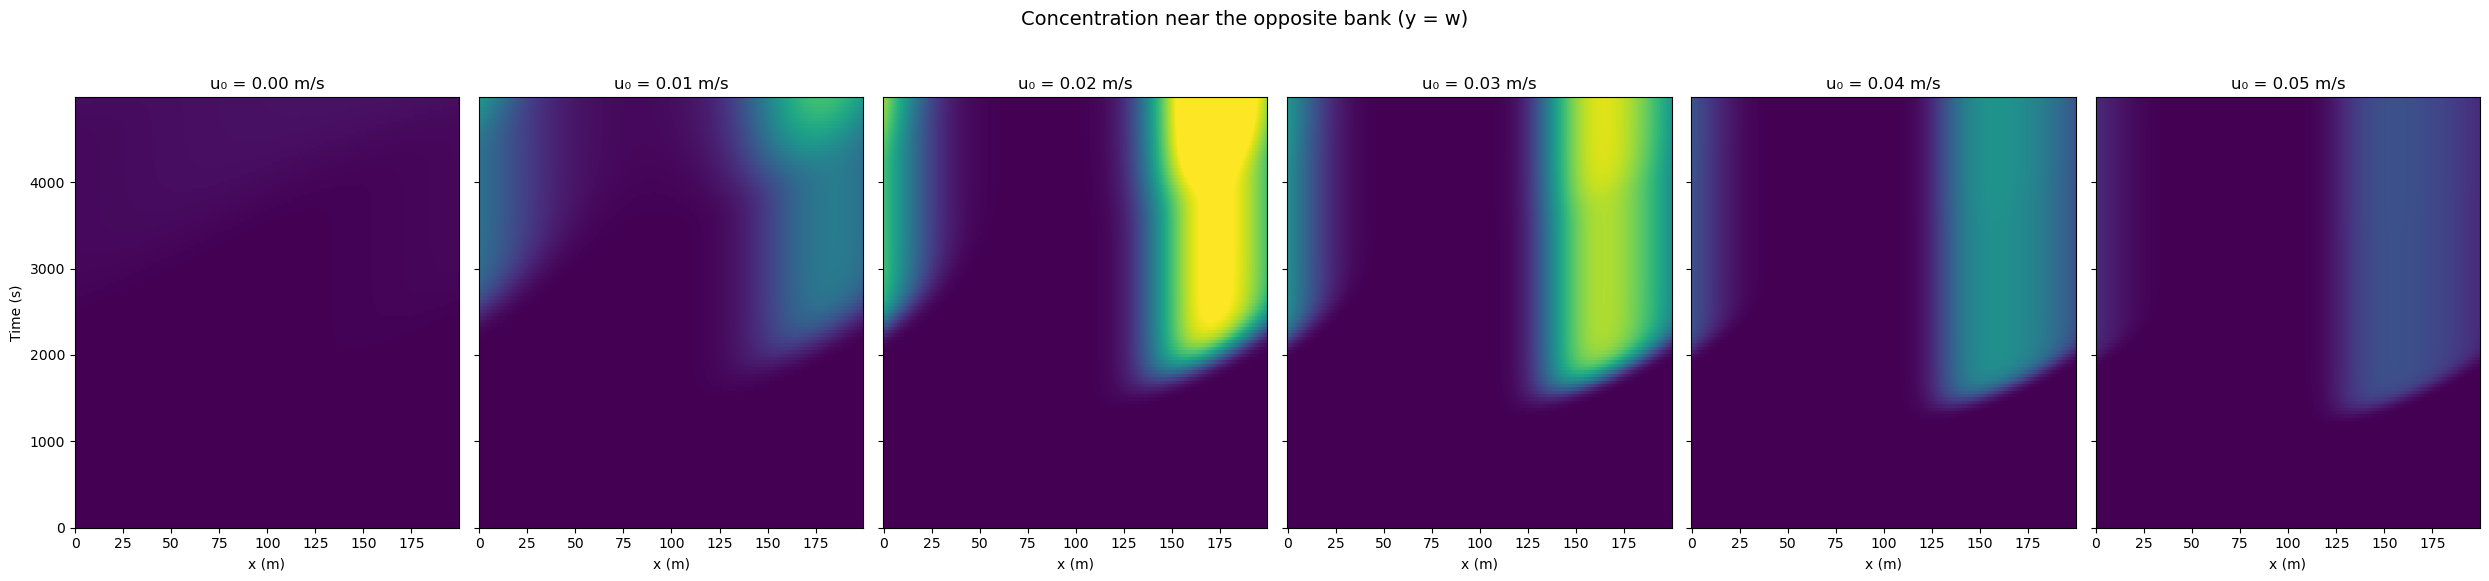

In [22]:
U0 = 0.1 
w  = 25.0
L  = 200.0 
kappa = 1e-2
S0, S_w, S_x, S_y, S_t = 2.0, 1.0, 10.0, 0.0, 1.0
Nx, Ny = 512, 64
stop_sim_time = 5000.0

def run_solver(u0=0.05, nx=1, ny=1):
    timestep = (L / Nx) / U0

    # coords/bases
    coords = d3.CartesianCoordinates('x','y')
    dist   = d3.Distributor(coords, dtype=np.float64)
    xbasis = d3.RealFourier(coords['x'], size=Nx, bounds=(0, L), dealias=3/2)
    ybasis = d3.ChebyshevT(coords['y'], size=Ny, bounds=(0, w), dealias=3/2)
    x, y   = dist.local_grids(xbasis, ybasis)
    ex, ey = coords.unit_vector_fields(dist)

    # fields
    c = dist.Field(name='c', bases=(xbasis, ybasis))
    u = dist.Field(name='u', bases=(xbasis, ybasis))
    v = dist.Field(name='v', bases=(xbasis, ybasis))
    tau_1 = dist.Field(name='tau_1', bases=xbasis)
    tau_2 = dist.Field(name='tau_2', bases=xbasis)

    # wavenumbers
    kx = 2*np.pi*nx / L
    ky = 2*np.pi*ny / w

    # velocities: base + fluctuations
    Umean = U0 * (1 - ((y - w/2)/(w/2))**2)
    u_fluc = u0 * np.cos(kx*x) * np.cos(ky*y)
    v_fluc = u0 * np.sin(kx*x) * np.sin(ky*y)
    u['g'] = Umean + u_fluc
    v['g'] = v_fluc

    # source
    S = dist.Field(name='S', bases=(xbasis, ybasis))
    S['g'] = S0*np.exp(-((x-S_x)**2)/S_w**2 - ((y-S_y)**2)/S_w**2)

    # operators
    lift_basis = ybasis.derivative_basis(1)
    lift = lambda A: d3.Lift(A, lift_basis, -1)
    grad_c = d3.grad(c) + ey*lift(tau_1)
    dx = lambda A: d3.Differentiate(A, coords['x'])
    cy = grad_c @ ey

    # bind constants for string parsing
    S_t_val = S_t
    kappa_val = kappa
    w_val = w

    # IVP
    problem = d3.IVP([c, tau_1, tau_2], namespace=locals())
    problem.add_equation("dt(c) + u*dx(c) + v*cy - kappa_val*div(grad_c) + lift(tau_2) = S/S_t_val")
    problem.add_equation("c(y=0) = 0")
    problem.add_equation("c(y=w_val) = 0")

    solver = problem.build_solver(d3.RK222)
    solver.stop_sim_time = stop_sim_time

    # time loop
    c.change_scales(1)
    c_save = [np.copy(c['g'])]
    t_save = [solver.sim_time]

    try:
        logger.info(f"Run: u0={u0:.3f}, nx={nx}, ny={ny}, dt={timestep:.3e}")
        while solver.proceed:
            solver.step(timestep)
            if (solver.iteration - 1) % 10 == 0:
                c.change_scales(1)
                c_save.append(np.copy(c['g']))
                t_save.append(solver.sim_time)
    finally:
        solver.log_stats()

    return np.array(c_save), np.array(t_save), x, y

# Iterating
u0_values = [0.0, 0.01, 0.02, 0.03, 0.04, 0.05]  

nx_val, ny_val = 1, 1               

runs = {}
for u0 in u0_values:
    c_save, t_save, xg, yg = run_solver(u0=u0, nx=nx_val, ny=ny_val)
    c_top = c_save[:, :, -1]   # shape (Nt, Nx)
    runs[u0] = dict(c_top=c_top, t=t_save)

# Common x vector for pcolormesh
x_vec = xg[:, 0]   # 1D x

all_vals = np.concatenate([runs[u0]['c_top'].ravel() for u0 in u0_values])
vmin = np.percentile(all_vals, 1)
vmax = np.percentile(all_vals, 99)

fig, axs = plt.subplots(1, len(u0_values), figsize=(4*len(u0_values)+1, 6), sharey=True)
if len(u0_values) == 1:
    axs = [axs]

for ax, u0 in zip(axs, u0_values):
    data = runs[u0]['c_top']  # (Nt, Nx)
    tvec = runs[u0]['t']
    pcm = ax.pcolormesh(x_vec, tvec, data, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_title(f"u₀ = {u0:.2f} m/s")
    ax.set_xlabel("x (m)")
axs[0].set_ylabel("Time (s)")

fig.suptitle("Concentration near the opposite bank (y = w)", fontsize=14, y=0.98)
plt.tight_layout(rect=[0, 0.02, 1, 0.95])
plt.show()

**ANSWER:** Above we have plots that display the effects of increased turbulent amplitude on the concentration at the opposite bank. We can see that the arrival of the pollutant to the opposite bank is slighly fast with a larger amplitude. However, we also see that the concentration of pollutants upon arrival are lower for larger turbulent amplitudes. Our findings also agree with the hypothesis of turbulent diffusion which asserts that transport of tracers is faster with turbulence than without. This can be shown by the differences between the runs with no turbulence, which had no pollutants reach the bank, and the runs with some turbulence, all of which had some pollutant reach the opposite bank. Our findings also suggest the existence of a critical turbulent amplitude whereby, upon arrival of the pollutants to the opposite bank, the pollution concentration is higher than for amplitudes smaller or larger than the critical amplitude. In the diagram above, it seems this critical amplitude occurs at roughly 0.02 for the parameters in our run. 

**Iterating through different values of k**

2025-11-12 08:44:19,108 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 0s, Remaining: 0s, Rate: 4.2e+00/s
2025-11-12 08:44:19,110 __main__ 0/1 INFO :: Run: u0=0.025, nx=0, ny=0, dt=3.906e+00
2025-11-12 08:44:22,008 solvers 0/1 INFO :: Simulation stop time reached.
2025-11-12 08:44:22,009 solvers 0/1 INFO :: Final iteration: 1280
2025-11-12 08:44:22,009 solvers 0/1 INFO :: Final sim time: 5000.0
2025-11-12 08:44:22,009 solvers 0/1 INFO :: Setup time (init - iter 0): 0.2762 sec
2025-11-12 08:44:22,009 solvers 0/1 INFO :: Warmup time (iter 0-10): 0.06322 sec
2025-11-12 08:44:22,010 solvers 0/1 INFO :: Run time (iter 10-end): 2.835 sec
2025-11-12 08:44:22,010 solvers 0/1 INFO :: CPU time (iter 10-end): 0.0007876 cpu-hr
2025-11-12 08:44:22,010 solvers 0/1 INFO :: Speed: 3.021e+07 mode-stages/cpu-sec
2025-11-12 08:44:22,581 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 1s, Remaining: 0s, Rate: 1.9e+00/s
2025-11-12 08:44:22,582 __main__ 0/1

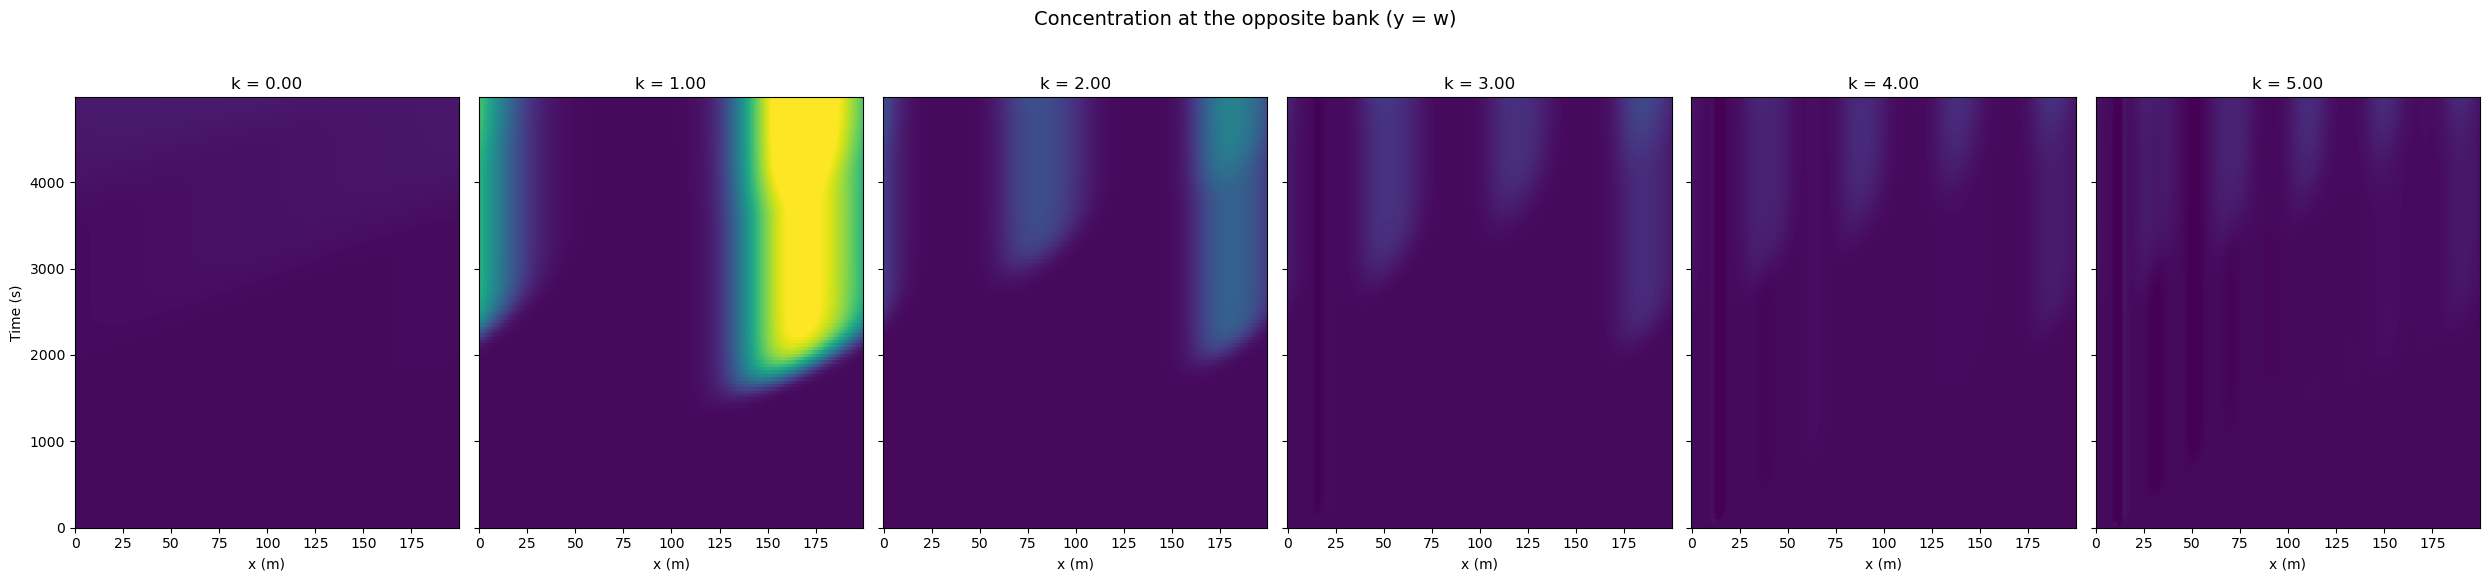

In [23]:
U0 = 0.1 
w  = 25.0
L  = 200.0 
kappa = 1e-2
S0, S_w, S_x, S_y, S_t = 2.0, 1.0, 10.0, 0.0, 1.0
Nx, Ny = 512, 64
stop_sim_time = 5000.0

def run_solver(u0=0.05, nx=1, ny=1):
    timestep = (L / Nx) / U0

    # coords/bases
    coords = d3.CartesianCoordinates('x','y')
    dist   = d3.Distributor(coords, dtype=np.float64)
    xbasis = d3.RealFourier(coords['x'], size=Nx, bounds=(0, L), dealias=3/2)
    ybasis = d3.ChebyshevT(coords['y'], size=Ny, bounds=(0, w), dealias=3/2)
    x, y   = dist.local_grids(xbasis, ybasis)
    ex, ey = coords.unit_vector_fields(dist)

    # fields
    c = dist.Field(name='c', bases=(xbasis, ybasis))
    u = dist.Field(name='u', bases=(xbasis, ybasis))
    v = dist.Field(name='v', bases=(xbasis, ybasis))
    tau_1 = dist.Field(name='tau_1', bases=xbasis)
    tau_2 = dist.Field(name='tau_2', bases=xbasis)

    # wavenumbers
    kx = 2*np.pi*nx / L
    ky = 2*np.pi*ny / w

    # velocities: base + fluctuations
    Umean = U0 * (1 - ((y - w/2)/(w/2))**2)
    u_fluc = u0 * np.cos(kx*x) * np.cos(ky*y)
    v_fluc = u0 * np.sin(kx*x) * np.sin(ky*y)
    u['g'] = Umean + u_fluc
    v['g'] = v_fluc

    # source
    S = dist.Field(name='S', bases=(xbasis, ybasis))
    S['g'] = S0*np.exp(-((x-S_x)**2)/S_w**2 - ((y-S_y)**2)/S_w**2)

    # operators
    lift_basis = ybasis.derivative_basis(1)
    lift = lambda A: d3.Lift(A, lift_basis, -1)
    grad_c = d3.grad(c) + ey*lift(tau_1)
    dx = lambda A: d3.Differentiate(A, coords['x'])
    cy = grad_c @ ey

    # bind constants for string parsing
    S_t_val = S_t
    kappa_val = kappa
    w_val = w

    # IVP
    problem = d3.IVP([c, tau_1, tau_2], namespace=locals())
    problem.add_equation("dt(c) + u*dx(c) + v*cy - kappa_val*div(grad_c) + lift(tau_2) = S/S_t_val")
    problem.add_equation("c(y=0) = 0")
    problem.add_equation("c(y=w_val) = 0")

    solver = problem.build_solver(d3.RK222)
    solver.stop_sim_time = stop_sim_time

    # time loop
    c.change_scales(1)
    c_save = [np.copy(c['g'])]
    t_save = [solver.sim_time]

    try:
        logger.info(f"Run: u0={u0:.3f}, nx={nx}, ny={ny}, dt={timestep:.3e}")
        while solver.proceed:
            solver.step(timestep)
            if (solver.iteration - 1) % 10 == 0:
                c.change_scales(1)
                c_save.append(np.copy(c['g']))
                t_save.append(solver.sim_time)
    finally:
        solver.log_stats()

    return np.array(c_save), np.array(t_save), x, y

# Iterating
wavenumbers = [0, 1, 2, 3, 4, 5]
u0 = 0.025        

runs = {}
for wave in wavenumbers:
    nx_val = wave
    ny_val = wave
    c_save, t_save, xg, yg = run_solver(u0=u0, nx=nx_val, ny=ny_val)
    c_top = c_save[:, :, -1]   # shape (Nt, Nx)
    runs[wave] = dict(c_top=c_top, t=t_save)

# Common x vector for pcolormesh
x_vec = xg[:, 0]   # 1D x

all_vals = np.concatenate([runs[wave]['c_top'].ravel() for wave in wavenumbers])
vmin = np.percentile(all_vals, 1)
vmax = np.percentile(all_vals, 99)

fig, axs = plt.subplots(1, len(wavenumbers), figsize=(4*len(wavenumbers)+1, 6), sharey=True)
if len(wavenumbers) == 1:
    axs = [axs]

for ax, wave in zip(axs, wavenumbers):
    data = runs[wave]['c_top']  # (Nt, Nx)
    tvec = runs[wave]['t']
    pcm = ax.pcolormesh(x_vec, tvec, data, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_title(f"k = {wave:.2f}")
    ax.set_xlabel("x (m)")
axs[0].set_ylabel("Time (s)")

fig.suptitle("Concentration at the opposite bank (y = w)", fontsize=14, y=0.98)
plt.tight_layout(rect=[0, 0.02, 1, 0.95])
plt.show()

**ANSWER:** Above we have plots that display the effects of increased wavenumber on the concentration at the opposite bank. An increase in the wavenumber prolongs the time required for the tracer to reach the opposite bank. This occurs because higher wavenumbers correspond to smaller eddy length scales $(\ell \sim 1/k)$, which reduce the efficiency of cross-stream mixing. Consequently, the effective turbulent diffusivity $\kappa_T \sim u_0 * \ell$ becomes smaller, slowing down the lateral transport of the pollutant. Our results also show that as the wavenumber increases, the pollutant concentration near the opposite bank decreases and becomes more spatially localized. The tracer tends to remain confined near specific regions that correspond to the periodicity of the velocity fluctuations. In other words, larger k values lead to finer, more localized structures in the concentration field and weaker overall cross-channel mixing.

## 3. Optional further investigations

* In the river pollution example, you might notice that the concentration field is mixed more effectively in the x-direction than in the y-direction. The combination of differential advection by the currents and cross-stream diffusion is very effective at mixing the plume in the x-direction. This is an example of Taylor dispersion (Taylor, 1953). Construct numerical experiments to quantify Taylor dispersion and its dependence on the current shear and the diffusivity. You could also separate the diffusivity into parts in the x and y directions with different coefficients.  If you set the x-component of the diffusivity to zero, then any spreading of the concentration in the x-direction should be due to Taylor dispersion.

* Try making the river speed a function of time. The easiest way to do this is to add a new equation so that Dedalus solves for the velocity in addition to the concentration field. For example, you could make the river speed decrease exponentially in time, or it could be sinusoidal in time.

* In the ocean mixing example, if $\kappa$ is a function of $x$ and $z$, what would this imply about the velocity field? You could even try writing a Dedalus script to solve the 2D advection/diffusion equation with a prescribed spatially-dependent $\kappa(x,z)$.


### References

Munk, W.H., 1966. Abyssal recipes. In Deep sea research and oceanographic abstracts (Vol. 13, No. 4, pp. 707-730). Elsevier.

Ferrari, R., Mashayek, A., McDougall, T.J., Nikurashin, M. and Campin, J.M., 2016. Turning ocean mixing upside down. Journal of Physical Oceanography, 46(7), pp.2239-2261.

Taylor, G.I., 1953. Dispersion of soluble matter in solvent flowing slowly through a tube. Proceedings of the Royal Society of London. Series A. Mathematical and Physical Sciences, 219(1137), pp.186-203.